In [ ]:
# ============================================================
# CELL 1 — Installs & Imports
# ============================================================

!pip install torch torchvision matplotlib seaborn scikit-learn numpy pandas -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report
from copy import deepcopy
import time
import random

# Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


100%|██████████| 170M/170M [00:12<00:00, 13.3MB/s]


Training samples   : 40000
Validation samples : 10000
Test samples       : 10000


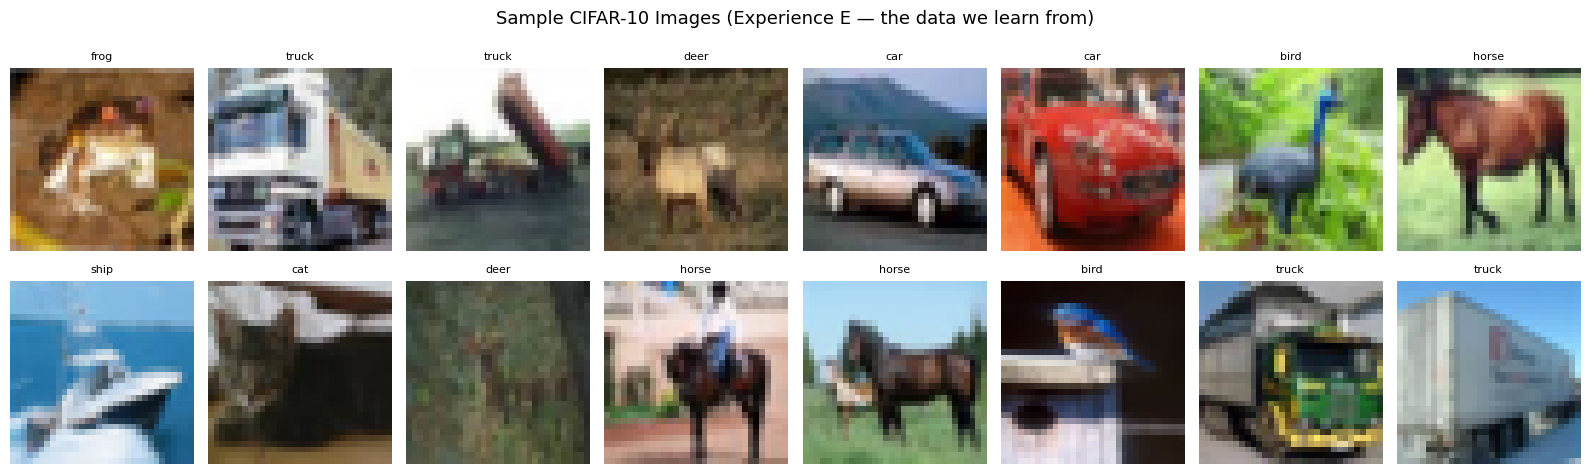

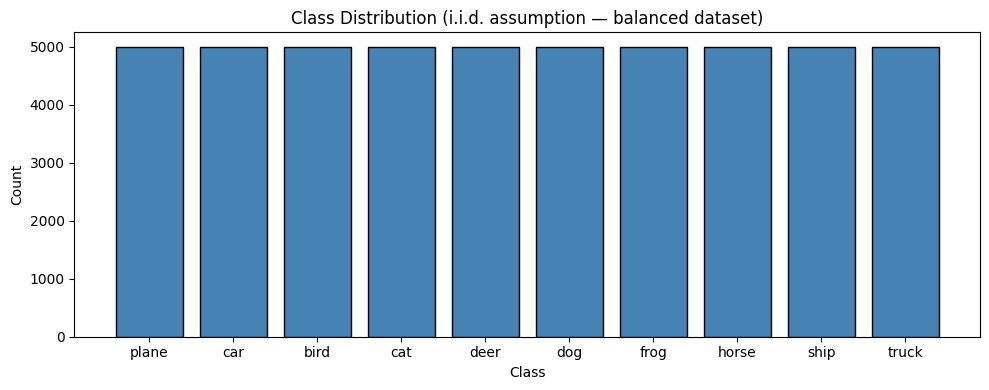

Class counts: {'plane': np.int64(5000), 'car': np.int64(5000), 'bird': np.int64(5000), 'cat': np.int64(5000), 'deer': np.int64(5000), 'dog': np.int64(5000), 'frog': np.int64(5000), 'horse': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


In [ ]:
# ============================================================
# CELL 2 — Dataset Loading & Exploration (Week 2: Experience E)
# Covers: design matrix, data distribution, i.i.d. assumption
# ============================================================

CLASSES = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Base transform (no augmentation) — used for val/test
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

# Augmented transform — used for training (Week 4: Data Augmentation)
augmented_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

# Download datasets
train_dataset_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                   download=True, transform=augmented_transform)
train_dataset_base = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                   download=True, transform=base_transform)
test_dataset       = torchvision.datasets.CIFAR10(root='./data', train=False,
                                                   download=True, transform=base_transform)

# Fixed 80/20 train-val split (Week 2: Hyperparameters & Validation Set)
n_train = int(0.8 * len(train_dataset_aug))
n_val   = len(train_dataset_aug) - n_train
train_idx = list(range(n_train))
val_idx   = list(range(n_train, len(train_dataset_aug)))

train_loader = DataLoader(Subset(train_dataset_aug,  train_idx), batch_size=128, shuffle=True,  num_workers=2)
val_loader   = DataLoader(Subset(train_dataset_base, val_idx),   batch_size=128, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,                           batch_size=128, shuffle=False, num_workers=2)

print(f"Training samples   : {len(train_idx)}")
print(f"Validation samples : {len(val_idx)}")
print(f"Test samples       : {len(test_dataset)}")

# ── Visualise sample images ──────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Sample CIFAR-10 Images (Experience E — the data we learn from)", fontsize=13)

raw_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=False,
                                          transform=transforms.ToTensor())
for i, ax in enumerate(axes.flat):
    img, label = raw_train[i]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[label], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

# ── Class distribution ───────────────────────────────────────
labels = [train_dataset_base[i][1] for i in range(len(train_dataset_base))]
counts = np.bincount(labels)

plt.figure(figsize=(10, 4))
plt.bar(CLASSES, counts, color='steelblue', edgecolor='black')
plt.title("Class Distribution (i.i.d. assumption — balanced dataset)")
plt.ylabel("Count")
plt.xlabel("Class")
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Class counts:", dict(zip(CLASSES, counts)))

Preparing NumPy arrays...
X_train shape: (40000, 3072)
  └─ rows = training examples (m=40000)
  └─ cols = features (32×32×3 = 3072)
y_train shape: (40000,)

Epoch  1/30 | LR: 0.05000 | Train Loss: 1.7760  Val Loss: 1.7468 | Train Acc: 0.413  Val Acc: 0.390
Epoch  2/30 | LR: 0.04750 | Train Loss: 1.5127  Val Loss: 1.6044 | Train Acc: 0.490  Val Acc: 0.434
Epoch  3/30 | LR: 0.04512 | Train Loss: 1.4018  Val Loss: 1.5657 | Train Acc: 0.527  Val Acc: 0.453
Epoch  4/30 | LR: 0.04287 | Train Loss: 1.3264  Val Loss: 1.5612 | Train Acc: 0.541  Val Acc: 0.455
Epoch  5/30 | LR: 0.04073 | Train Loss: 1.2555  Val Loss: 1.5683 | Train Acc: 0.553  Val Acc: 0.456
Epoch  6/30 | LR: 0.03869 | Train Loss: 1.1984  Val Loss: 1.5369 | Train Acc: 0.582  Val Acc: 0.473
Epoch  7/30 | LR: 0.03675 | Train Loss: 1.1464  Val Loss: 1.5054 | Train Acc: 0.612  Val Acc: 0.493
Epoch  8/30 | LR: 0.03492 | Train Loss: 1.1003  Val Loss: 1.5777 | Train Acc: 0.594  Val Acc: 0.464
Epoch  9/30 | LR: 0.03317 | Train Loss: 1.

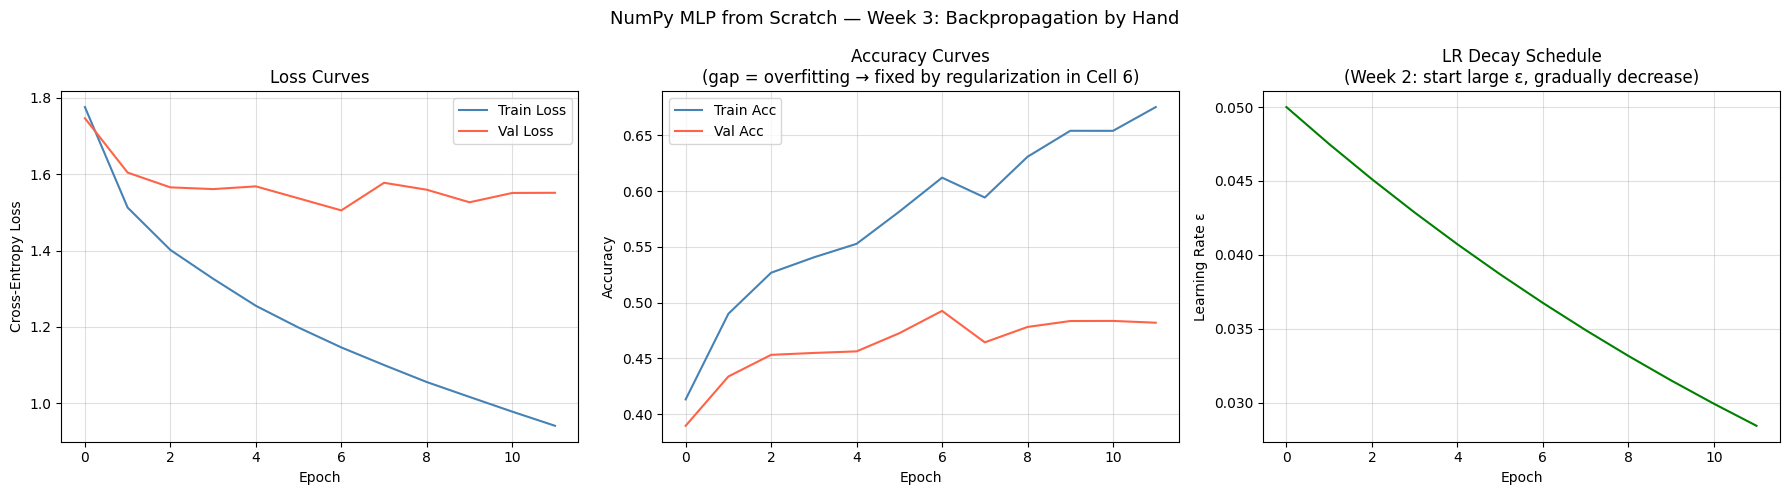


NumPy MLP Results:
  Train Accuracy : 0.6120
  Val Accuracy   : 0.4926
  Overfitting Gap: 0.1194  ← this is expected and intentional!

Note: ~50% val accuracy is normal for a plain MLP on CIFAR-10.
The PyTorch models in Cell 6 will improve this significantly.


In [ ]:
# ============================================================
# CELL 3 — NumPy MLP from Scratch (improved)
# Covers: forward pass, backprop, SGD with LR decay,
#         cross-entropy, ReLU
# Week 2: SGD θ←θ−ε∇J, MLE→cross-entropy
# Week 3: backprop, chain rule, activation functions
# ============================================================

class NumpyMLP:
    """
    2-layer MLP trained entirely with NumPy.
    Architecture: 3072 → 256 → 128 → 10
    Loss:         Cross-entropy (derived from MLE, Week 2 & 3)
    Optimizer:    Mini-batch SGD with learning rate decay
    """

    def __init__(self, input_dim=3072, hidden1=256, hidden2=128,
                 num_classes=10, lr=0.05):
        self.lr = lr
        self.init_lr = lr

        # Xavier initialisation — balances gradient flow across layers
        self.W1 = np.random.randn(input_dim, hidden1) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros(hidden1)
        self.W2 = np.random.randn(hidden1, hidden2) * np.sqrt(2.0 / hidden1)
        self.b2 = np.zeros(hidden2)
        self.W3 = np.random.randn(hidden2, num_classes) * np.sqrt(2.0 / hidden2)
        self.b3 = np.zeros(num_classes)

    # ── Activation functions (Week 3: Hidden Units) ──────────
    def relu(self, z):
        return np.maximum(0, z)

    def relu_grad(self, z):
        # Gradient of ReLU: 1 where z>0, 0 elsewhere
        return (z > 0).astype(float)

    def softmax(self, z):
        # Subtract max per row for numerical stability
        z_stable = z - z.max(axis=1, keepdims=True)
        exp_z = np.exp(z_stable)
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    # ── Forward pass (Algorithm 6.3, Week 3 slides) ───────────
    def forward(self, X):
        self.X  = X
        self.a1 = X  @ self.W1 + self.b1       # pre-activation layer 1
        self.h1 = self.relu(self.a1)            # post-activation layer 1
        self.a2 = self.h1 @ self.W2 + self.b2  # pre-activation layer 2
        self.h2 = self.relu(self.a2)            # post-activation layer 2
        self.a3 = self.h2 @ self.W3 + self.b3  # pre-activation output
        self.y_hat = self.softmax(self.a3)      # categorical distribution
        return self.y_hat

    # ── Cross-entropy loss (MLE under categorical, Week 2 & 3)─
    def loss(self, y_hat, y_true):
        n = y_true.shape[0]
        log_probs = -np.log(y_hat[np.arange(n), y_true] + 1e-9)
        return np.mean(log_probs)

    # ── Backward pass (Algorithm 6.4, Week 3 slides) ──────────
    def backward(self, y_true):
        n = y_true.shape[0]

        # Output gradient: softmax + cross-entropy combined derivative
        delta3 = self.y_hat.copy()
        delta3[np.arange(n), y_true] -= 1
        delta3 /= n

        dW3 = self.h2.T @ delta3
        db3 = delta3.sum(axis=0)

        # Layer 2: chain rule through ReLU (⊙ = element-wise)
        delta2 = (delta3 @ self.W3.T) * self.relu_grad(self.a2)
        dW2    = self.h1.T @ delta2
        db2    = delta2.sum(axis=0)

        # Layer 1: chain rule through ReLU
        delta1 = (delta2 @ self.W2.T) * self.relu_grad(self.a1)
        dW1    = self.X.T @ delta1
        db1    = delta1.sum(axis=0)

        # SGD update rule: θ ← θ − ε∇J  (Week 2)
        self.W3 -= self.lr * dW3;  self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        return (self.predict(X) == y).mean()

    def set_lr(self, new_lr):
        self.lr = new_lr


# ── Training loop with LR decay & early stopping ─────────────
def train_numpy_mlp(model, X_train, y_train, X_val, y_val,
                    epochs=30, batch_size=256,
                    lr_decay=0.95, patience=5):
    """
    Trains the NumPy MLP with:
    - Mini-batch SGD  (Week 2: stochastic gradient descent)
    - Step LR decay   (Week 2: learning rate scheduling)
    - Early stopping  (Week 4: stop when val loss stops improving)
    """
    n = X_train.shape[0]
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'lr':         []
    }

    best_val_loss   = float('inf')
    best_weights    = None
    patience_count  = 0

    for epoch in range(epochs):

        # ── LR decay: multiply lr by 0.95 each epoch ─────────
        # Week 2: start large ε, gradually decrease over training
        model.set_lr(model.init_lr * (lr_decay ** epoch))

        # ── Shuffle training data ─────────────────────────────
        idx = np.random.permutation(n)
        X_shuffled = X_train[idx]
        y_shuffled = y_train[idx]

        # ── Mini-batch loop ───────────────────────────────────
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            Xb = X_shuffled[start : start + batch_size]
            yb = y_shuffled[start : start + batch_size]
            y_hat      = model.forward(Xb)
            epoch_loss += model.loss(y_hat, yb) * len(Xb)
            model.backward(yb)

        # ── Epoch metrics ─────────────────────────────────────
        train_loss = epoch_loss / n

        # Compute val loss in chunks to avoid memory issues
        val_preds  = model.forward(X_val)
        val_loss   = model.loss(val_preds, y_val)
        train_acc  = model.accuracy(X_train, y_train)
        val_acc    = model.accuracy(X_val, y_val)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(model.lr)

        print(f"Epoch {epoch+1:>2}/{epochs} | "
              f"LR: {model.lr:.5f} | "
              f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f} | "
              f"Train Acc: {train_acc:.3f}  Val Acc: {val_acc:.3f}")

        # ── Early stopping check ──────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
            # Save best weights
            best_weights = {
                'W1': model.W1.copy(), 'b1': model.b1.copy(),
                'W2': model.W2.copy(), 'b2': model.b2.copy(),
                'W3': model.W3.copy(), 'b3': model.b3.copy(),
            }
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"\n→ Early stopping at epoch {epoch+1} "
                      f"(val loss hasn't improved for {patience} epochs)")
                break

    # Restore best weights
    if best_weights:
        model.W1, model.b1 = best_weights['W1'], best_weights['b1']
        model.W2, model.b2 = best_weights['W2'], best_weights['b2']
        model.W3, model.b3 = best_weights['W3'], best_weights['b3']
        print("→ Best weights restored.")

    return history


# ── Prepare flat NumPy arrays ─────────────────────────────────
# CIFAR-10 images: 32×32×3 = 3072 features per sample
# This is the "design matrix X" from Week 2
print("Preparing NumPy arrays...")

X_train_np = np.array([
    train_dataset_base[i][0].numpy().flatten() for i in train_idx
])
y_train_np = np.array([train_dataset_base[i][1] for i in train_idx])

X_val_np = np.array([
    train_dataset_base[i][0].numpy().flatten() for i in val_idx
])
y_val_np = np.array([train_dataset_base[i][1] for i in val_idx])

print(f"X_train shape: {X_train_np.shape}")
print(f"  └─ rows = training examples (m={len(train_idx)})")
print(f"  └─ cols = features (32×32×3 = 3072)")
print(f"y_train shape: {y_train_np.shape}\n")

# ── Train ─────────────────────────────────────────────────────
set_seed(42)
numpy_model   = NumpyMLP(lr=0.05)
numpy_history = train_numpy_mlp(
    numpy_model, X_train_np, y_train_np, X_val_np, y_val_np,
    epochs=30, batch_size=256, lr_decay=0.95, patience=5
)

# ── Plot training curves ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("NumPy MLP from Scratch — Week 3: Backpropagation by Hand", fontsize=13)

# Loss
axes[0].plot(numpy_history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(numpy_history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Loss Curves")
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Accuracy
axes[1].plot(numpy_history['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(numpy_history['val_acc'],   label='Val Acc',   color='tomato')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curves\n(gap = overfitting → fixed by regularization in Cell 6)")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

# Learning rate schedule
axes[2].plot(numpy_history['lr'], color='green')
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning Rate ε")
axes[2].set_title("LR Decay Schedule\n(Week 2: start large ε, gradually decrease)")
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('numpy_mlp_curves.png', dpi=150)
plt.show()

# ── Final numbers ─────────────────────────────────────────────
final_train_acc = numpy_model.accuracy(X_train_np, y_train_np)
final_val_acc   = numpy_model.accuracy(X_val_np,   y_val_np)
gen_gap         = final_train_acc - final_val_acc

print(f"\nNumPy MLP Results:")
print(f"  Train Accuracy : {final_train_acc:.4f}")
print(f"  Val Accuracy   : {final_val_acc:.4f}")
print(f"  Overfitting Gap: {gen_gap:.4f}  ← this is expected and intentional!")
print(f"\nNote: ~50% val accuracy is normal for a plain MLP on CIFAR-10.")
print(f"The PyTorch models in Cell 6 will improve this significantly.")

In [ ]:
# ============================================================
# CELL 4 — PyTorch Model Definitions
# Covers: architecture design, depth vs width (Week 3)
# All 5 models share the same training loop — fair comparison
# ============================================================

# ── Base MLP (no regularization — our baseline) ──────────────
class BaseMLP(nn.Module):
    """
    Baseline MLP — no regularization.
    Demonstrates overfitting when capacity is high.
    Week 3: feedforward network, ReLU activations.
    """
    def __init__(self, input_dim=3072, hidden=512, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, num_classes)
        )
    def forward(self, x):
        return self.net(x)


# ── L2-Regularized MLP (Weight Decay, Week 2 & 4) ────────────
class L2MLP(nn.Module):
    """
    Same architecture as BaseMLP.
    L2 regularization applied via weight_decay in the optimizer.
    Week 2: J(w) = MSE + λw^Tw
    Week 4: Ω(θ) = ½||w||₂²
    """
    def __init__(self, input_dim=3072, hidden=512, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, num_classes)
        )
    def forward(self, x):
        return self.net(x)


# ── Dropout MLP (Week 4: Dropout) ────────────────────────────
class DropoutMLP(nn.Module):
    """
    Dropout applied after each hidden layer.
    p=0.5 for hidden layers (standard from Goodfellow).
    Inverted dropout used by PyTorch by default.
    Week 4: approximates training ensemble of 2^n subnetworks.
    """
    def __init__(self, input_dim=3072, hidden=512, num_classes=10, drop_p=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(drop_p),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(drop_p),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Dropout(drop_p),
            nn.Linear(hidden // 2, num_classes)
        )
    def forward(self, x):
        return self.net(x)


# ── Batch Norm MLP (Week 4: Batch Normalization) ─────────────
class BatchNormMLP(nn.Module):
    """
    Batch normalization after each linear layer, before activation.
    γ and β are learnable; running stats used at inference.
    Week 4: reduces internal covariate shift, acts as regularizer.
    """
    def __init__(self, input_dim=3072, hidden=512, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, num_classes)
        )
    def forward(self, x):
        return self.net(x)


# ── Full Regularization MLP (everything combined) ────────────
class FullRegMLP(nn.Module):
    """
    Combines: Dropout + Batch Normalization + L2 (via optimizer).
    Also uses Label Smoothing loss and Data Augmentation loader.
    The kitchen-sink model — our best expected performer.
    """
    def __init__(self, input_dim=3072, hidden=512, num_classes=10, drop_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(drop_p),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(drop_p),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Dropout(drop_p),
            nn.Linear(hidden // 2, num_classes)
        )
    def forward(self, x):
        return self.net(x)


# ── Print architecture summary ────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models_info = {
    'BaseMLP':      BaseMLP(),
    'L2MLP':        L2MLP(),
    'DropoutMLP':   DropoutMLP(),
    'BatchNormMLP': BatchNormMLP(),
    'FullRegMLP':   FullRegMLP(),
}

print("Model Architectures:")
print(f"{'Model':<16} {'Parameters':>12}")
print("-" * 30)
for name, m in models_info.items():
    print(f"{name:<16} {count_params(m):>12,}")

Model Architectures:
Model              Parameters
------------------------------
BaseMLP             1,969,930
L2MLP               1,969,930
DropoutMLP          1,969,930
BatchNormMLP        1,972,490
FullRegMLP          1,972,490


In [ ]:
# ============================================================
# CELL 5 — Universal Training & Evaluation Engine
# Covers: training loop, early stopping, performance metrics
# Week 2: train/val/test split, performance measure P
# Week 4: Early Stopping (Algorithm 7.1)
# ============================================================

def train_model(model, train_loader, val_loader,
                optimizer, criterion,
                epochs=30, patience=7,
                model_name="model"):
    """
    Full training loop with:
    - Early stopping (Week 4 Algorithm 7.1)
    - Validation monitoring (Week 2: test on unseen data)
    - Best model checkpointing
    """
    model = model.to(DEVICE)
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  []
    }

    best_val_loss = float('inf')
    best_weights  = None
    patience_count = 0
    best_epoch    = 0

    for epoch in range(epochs):
        # ── Training phase ───────────────────────────────────
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()           # autograd handles all gradients
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # ── Validation phase ─────────────────────────────────
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                val_loss_sum += loss.item() * images.size(0)
                _, predicted  = outputs.max(1)
                val_correct  += predicted.eq(labels).sum().item()
                val_total    += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # ── Early stopping (Week 4: Algorithm 7.1) ───────────
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_weights   = deepcopy(model.state_dict())
            best_epoch     = epoch + 1
            patience_count = 0
        else:
            patience_count += 1

        if epoch % 5 == 0 or patience_count == patience:
            print(f"  [{model_name}] Epoch {epoch+1:>3} | "
                  f"Train {train_loss:.4f}/{train_acc:.3f} | "
                  f"Val {val_loss:.4f}/{val_acc:.3f} | "
                  f"Patience {patience_count}/{patience}")

        if patience_count >= patience:
            print(f"  → Early stopping triggered at epoch {epoch+1} "
                  f"(best epoch: {best_epoch})")
            break

    # Restore best weights
    model.load_state_dict(best_weights)
    history['best_epoch'] = best_epoch
    return model, history


def evaluate_model(model, loader, criterion):
    """Full evaluation: loss, accuracy, per-class metrics."""
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    avg_loss   = total_loss / len(all_labels)
    accuracy   = (all_preds == all_labels).mean()

    return avg_loss, accuracy, all_preds, all_labels


def plot_training_curves(histories_dict, title="Training Curves"):
    """Plot loss and accuracy curves for all models side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(title, fontsize=14)
    colors = plt.cm.tab10(np.linspace(0, 1, len(histories_dict)))

    for (name, hist), color in zip(histories_dict.items(), colors):
        axes[0].plot(hist['train_loss'], linestyle='--', color=color, alpha=0.6)
        axes[0].plot(hist['val_loss'],   linestyle='-',  color=color, label=name)
        axes[1].plot(hist['train_acc'],  linestyle='--', color=color, alpha=0.6)
        axes[1].plot(hist['val_acc'],    linestyle='-',  color=color, label=name)

    for ax, ylabel, title_suffix in zip(axes,
                                         ['Loss', 'Accuracy'],
                                         ['Cross-Entropy Loss', 'Accuracy']):
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(title_suffix)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.4)
        ax.annotate("Solid = Val  |  Dashed = Train",
                    xy=(0.02, 0.02), xycoords='axes fraction', fontsize=8, color='gray')

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=150)
    plt.show()

print("Training engine ready.")

Training engine ready.


Training 1/5: BaseMLP (no regularization)
  [Baseline] Epoch   1 | Train 1.9536/0.289 | Val 1.7929/0.354 | Patience 0/8
  [Baseline] Epoch   6 | Train 1.5088/0.459 | Val 1.4811/0.478 | Patience 0/8
  [Baseline] Epoch  11 | Train 1.4020/0.496 | Val 1.4283/0.492 | Patience 0/8
  [Baseline] Epoch  16 | Train 1.3315/0.524 | Val 1.3764/0.521 | Patience 0/8
  [Baseline] Epoch  21 | Train 1.2759/0.541 | Val 1.3254/0.536 | Patience 0/8
  [Baseline] Epoch  26 | Train 1.2325/0.559 | Val 1.3056/0.539 | Patience 0/8
  [Baseline] Epoch  31 | Train 1.1962/0.571 | Val 1.3261/0.536 | Patience 5/8
  [Baseline] Epoch  34 | Train 1.1679/0.580 | Val 1.3117/0.540 | Patience 8/8
  → Early stopping triggered at epoch 34 (best epoch: 26)

Training 2/5: L2 MLP (weight_decay=1e-4)
  [L2 Reg] Epoch   1 | Train 1.9531/0.287 | Val 1.7323/0.373 | Patience 0/8
  [L2 Reg] Epoch   6 | Train 1.5078/0.457 | Val 1.5118/0.468 | Patience 1/8
  [L2 Reg] Epoch  11 | Train 1.3986/0.498 | Val 1.4201/0.503 | Patience 1/8
  [L2 

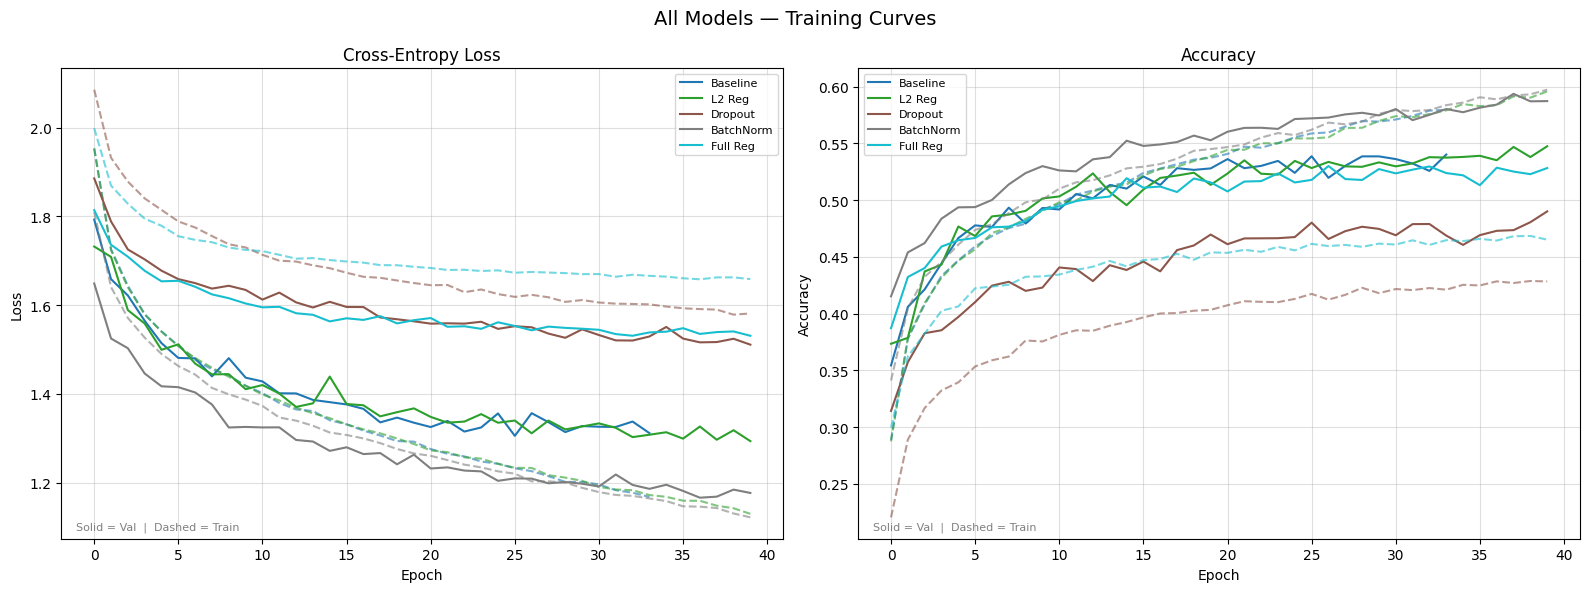


All models trained.


In [ ]:
# ============================================================
# CELL 6 — Train All 5 Models
# Covers: L1/L2, Dropout, BatchNorm, Label Smoothing,
#         Data Augmentation, Early Stopping
# Week 4: complete regularization comparison
# ============================================================

EPOCHS  = 40
PATIENCE = 8

# Label smoothing (Week 4: Noise Robustness & Label Smoothing)
# Replaces hard 0/1 targets with ε/(k-1) and 1-ε
criterion_smooth = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion_hard   = nn.CrossEntropyLoss()

all_histories = {}

# ── 1. Baseline (no regularization) ──────────────────────────
print("=" * 60)
print("Training 1/5: BaseMLP (no regularization)")
print("=" * 60)
base_model = BaseMLP().to(DEVICE)
base_opt   = optim.SGD(base_model.parameters(), lr=0.01, momentum=0.9)
base_model, all_histories['Baseline'] = train_model(
    base_model, train_loader, val_loader,
    base_opt, criterion_hard,
    epochs=EPOCHS, patience=PATIENCE, model_name="Baseline"
)

# ── 2. L2 Regularization (weight decay in optimizer) ─────────
print("\n" + "=" * 60)
print("Training 2/5: L2 MLP (weight_decay=1e-4)")
print("=" * 60)
l2_model = L2MLP().to(DEVICE)
l2_opt   = optim.SGD(l2_model.parameters(), lr=0.01,
                      momentum=0.9, weight_decay=1e-4)   # ← L2 here
l2_model, all_histories['L2 Reg'] = train_model(
    l2_model, train_loader, val_loader,
    l2_opt, criterion_hard,
    epochs=EPOCHS, patience=PATIENCE, model_name="L2 Reg"
)

# ── 3. Dropout ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Training 3/5: DropoutMLP (p=0.5)")
print("=" * 60)
drop_model = DropoutMLP(drop_p=0.5).to(DEVICE)
drop_opt   = optim.SGD(drop_model.parameters(), lr=0.01, momentum=0.9)
drop_model, all_histories['Dropout'] = train_model(
    drop_model, train_loader, val_loader,
    drop_opt, criterion_hard,
    epochs=EPOCHS, patience=PATIENCE, model_name="Dropout"
)

# ── 4. Batch Normalization ────────────────────────────────────
print("\n" + "=" * 60)
print("Training 4/5: BatchNormMLP")
print("=" * 60)
bn_model = BatchNormMLP().to(DEVICE)
bn_opt   = optim.SGD(bn_model.parameters(), lr=0.01, momentum=0.9)
bn_model, all_histories['BatchNorm'] = train_model(
    bn_model, train_loader, val_loader,
    bn_opt, criterion_hard,
    epochs=EPOCHS, patience=PATIENCE, model_name="BatchNorm"
)

# ── 5. Full Regularization (everything) ──────────────────────
print("\n" + "=" * 60)
print("Training 5/5: FullRegMLP (Dropout + BN + L2 + Label Smoothing + Augmentation)")
print("=" * 60)
full_model = FullRegMLP(drop_p=0.3).to(DEVICE)
full_opt   = optim.Adam(full_model.parameters(), lr=1e-3, weight_decay=1e-4)
full_model, all_histories['Full Reg'] = train_model(
    full_model, train_loader, val_loader,
    full_opt, criterion_smooth,        # ← label smoothing here
    epochs=EPOCHS, patience=PATIENCE, model_name="Full Reg"
)

# ── Plot all training curves together ────────────────────────
plot_training_curves(all_histories, title="All Models — Training Curves")
print("\nAll models trained.")

Bias-Variance Analysis on VALIDATION SET only
(Test set untouched still)

Baseline     | Train 0.568 | Val 0.539 | Gen Gap +0.1080 | Best Epoch 26
L2 Reg       | Train 0.601 | Val 0.547 | Gen Gap +0.1843 | Best Epoch 40
Dropout      | Train 0.488 | Val 0.490 | Gen Gap +0.0563 | Best Epoch 40
BatchNorm    | Train 0.605 | Val 0.584 | Gen Gap +0.0665 | Best Epoch 37
Full Reg     | Train 0.518 | Val 0.528 | Gen Gap -0.0202 | Best Epoch 40


/tmp/ipykernel_7549/2685308650.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(names, rotation=15)


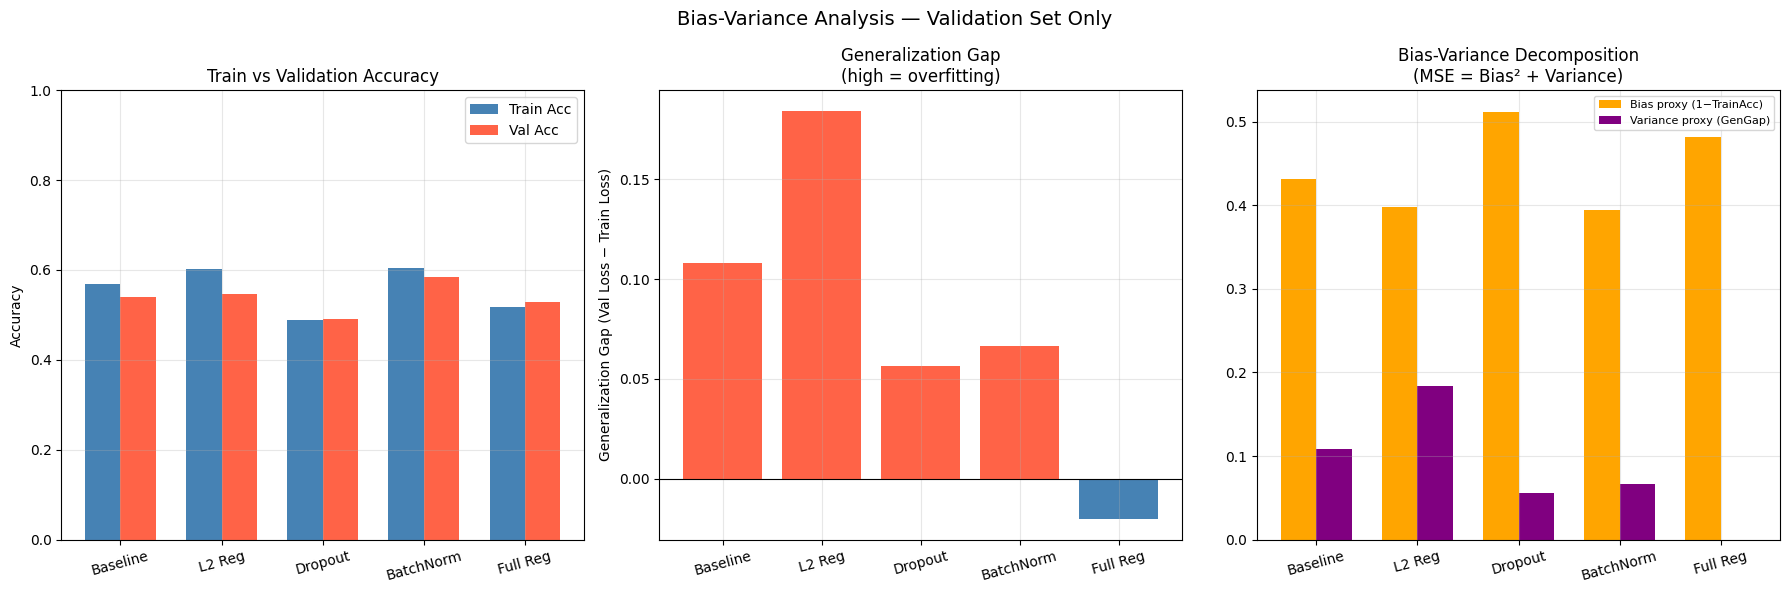

In [ ]:
# ============================================================
# CELL 7 — Bias-Variance Analysis (validation set only)
# NO test set used here — Week 2 golden rule
# ============================================================

print("Bias-Variance Analysis on VALIDATION SET only")
print("(Test set untouched still)\n")

val_results = {}
trained_models = {
    'Baseline':  (base_model,  nn.CrossEntropyLoss()),
    'L2 Reg':    (l2_model,    nn.CrossEntropyLoss()),
    'Dropout':   (drop_model,  nn.CrossEntropyLoss()),
    'BatchNorm': (bn_model,    nn.CrossEntropyLoss()),
    'Full Reg':  (full_model,  nn.CrossEntropyLoss(label_smoothing=0.1)),
}

for name, (model, crit) in trained_models.items():
    tr_loss, tr_acc, _, _   = evaluate_model(model, train_loader, crit)
    val_loss, val_acc, _, _ = evaluate_model(model, val_loader,   crit)
    gen_gap = val_loss - tr_loss

    val_results[name] = {
        'train_loss': tr_loss,  'train_acc': tr_acc,
        'val_loss':   val_loss, 'val_acc':   val_acc,
        'gen_gap':    gen_gap,
        'best_epoch': all_histories[name]['best_epoch']
    }
    print(f"{name:<12} | Train {tr_acc:.3f} | Val {val_acc:.3f} | "
          f"Gen Gap {gen_gap:+.4f} | Best Epoch {val_results[name]['best_epoch']}")

# ── Bias-Variance bar chart ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Bias-Variance Analysis — Validation Set Only", fontsize=14)

names      = list(val_results.keys())
train_accs = [val_results[n]['train_acc'] for n in names]
val_accs   = [val_results[n]['val_acc']   for n in names]
gen_gaps   = [val_results[n]['gen_gap']   for n in names]

x = np.arange(len(names))
w = 0.35

axes[0].bar(x - w/2, train_accs, w, label='Train Acc', color='steelblue')
axes[0].bar(x + w/2, val_accs,   w, label='Val Acc',   color='tomato')
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=15)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Train vs Validation Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

axes[1].bar(names, gen_gaps,
            color=['tomato' if g > 0.05 else 'steelblue' for g in gen_gaps])
axes[1].set_ylabel("Generalization Gap (Val Loss − Train Loss)")
axes[1].set_title("Generalization Gap\n(high = overfitting)")
axes[1].set_xticklabels(names, rotation=15)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

bias_proxy     = [1 - ta for ta in train_accs]
variance_proxy = [max(0, g) for g in gen_gaps]
axes[2].bar(x - w/2, bias_proxy,     w, label='Bias proxy (1−TrainAcc)',  color='orange')
axes[2].bar(x + w/2, variance_proxy, w, label='Variance proxy (GenGap)', color='purple')
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=15)
axes[2].set_title("Bias-Variance Decomposition\n(MSE = Bias² + Variance)")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bias_variance_analysis.png', dpi=150)
plt.show()

Running 5-Fold Cross-Validation on FullRegMLP...
(every sample used for testing exactly once)

── Fold 1/5 ──────────────────────────
  [Fold-1] Epoch   1 | Train 1.8584/0.375 | Val 1.7042/0.448 | Patience 0/5
  [Fold-1] Epoch   6 | Train 1.5467/0.525 | Val 1.5418/0.523 | Patience 0/5
  [Fold-1] Epoch  11 | Train 1.4585/0.567 | Val 1.5082/0.540 | Patience 1/5
  Fold 1 Val Accuracy: 0.5559

── Fold 2/5 ──────────────────────────
  [Fold-2] Epoch   1 | Train 1.8588/0.378 | Val 1.6817/0.464 | Patience 0/5
  [Fold-2] Epoch   6 | Train 1.5490/0.522 | Val 1.5307/0.531 | Patience 0/5
  [Fold-2] Epoch  11 | Train 1.4578/0.570 | Val 1.4889/0.548 | Patience 0/5
  Fold 2 Val Accuracy: 0.5503

── Fold 3/5 ──────────────────────────
  [Fold-3] Epoch   1 | Train 1.8630/0.375 | Val 1.7022/0.447 | Patience 0/5
  [Fold-3] Epoch   6 | Train 1.5473/0.525 | Val 1.5352/0.526 | Patience 0/5
  [Fold-3] Epoch  11 | Train 1.4584/0.568 | Val 1.4952/0.545 | Patience 0/5
  Fold 3 Val Accuracy: 0.5489

── Fold 4/5

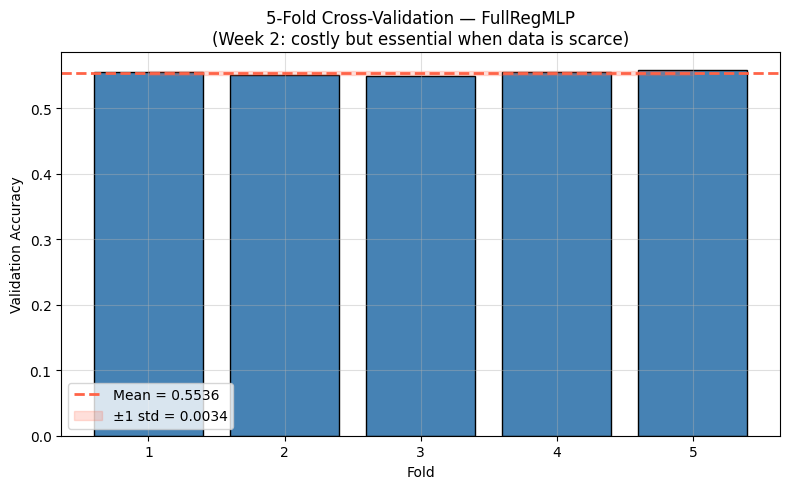

In [ ]:
# ============================================================
# CELL 8 — K-Fold Cross-Validation
# Covers: K-fold CV on the best model configuration
# Week 2: k-fold cross validation, every sample tested once
# ============================================================

print("Running 5-Fold Cross-Validation on FullRegMLP...")
print("(every sample used for testing exactly once)\n")

K       = 5
KFOLD_EPOCHS   = 15
kf      = KFold(n_splits=K, shuffle=True, random_state=42)

# Use the base (non-augmented) full training dataset for CV
full_train_dataset = train_dataset_base
all_indices        = list(range(len(full_train_dataset)))

fold_results = []

for fold, (train_idx_cv, val_idx_cv) in enumerate(kf.split(all_indices)):
    print(f"── Fold {fold+1}/{K} ──────────────────────────")

    fold_train_loader = DataLoader(
        Subset(full_train_dataset, train_idx_cv),
        batch_size=128, shuffle=True, num_workers=2
    )
    fold_val_loader = DataLoader(
        Subset(full_train_dataset, val_idx_cv),
        batch_size=128, shuffle=False, num_workers=2
    )

    cv_model = FullRegMLP(drop_p=0.3).to(DEVICE)
    cv_opt   = optim.Adam(cv_model.parameters(), lr=1e-3, weight_decay=1e-4)
    cv_crit  = nn.CrossEntropyLoss(label_smoothing=0.1)

    cv_model, cv_hist = train_model(
        cv_model, fold_train_loader, fold_val_loader,
        cv_opt, cv_crit,
        epochs=KFOLD_EPOCHS, patience=5, model_name=f"Fold-{fold+1}"
    )

    _, fold_acc, _, _ = evaluate_model(cv_model, fold_val_loader, cv_crit)
    fold_results.append(fold_acc)
    print(f"  Fold {fold+1} Val Accuracy: {fold_acc:.4f}\n")

mean_cv = np.mean(fold_results)
std_cv  = np.std(fold_results)
print(f"\n{'='*50}")
print(f"K-Fold CV Results (K={K}):")
for i, acc in enumerate(fold_results):
    print(f"  Fold {i+1}: {acc:.4f}")
print(f"\n  Mean Accuracy : {mean_cv:.4f}")
print(f"  Std Deviation : {std_cv:.4f}")
print(f"  95% CI        : ({mean_cv - 1.96*std_cv:.4f}, {mean_cv + 1.96*std_cv:.4f})")
print(f"  (SE = σ/√m = {std_cv/np.sqrt(K):.4f})")

# ── Plot fold results ─────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.bar(range(1, K+1), fold_results, color='steelblue', edgecolor='black')
plt.axhline(mean_cv, color='tomato', linestyle='--', linewidth=2, label=f'Mean = {mean_cv:.4f}')
plt.fill_between(range(1, K+1),
                  mean_cv - std_cv, mean_cv + std_cv,
                  alpha=0.2, color='tomato', label=f'±1 std = {std_cv:.4f}')
plt.xlabel("Fold"); plt.ylabel("Validation Accuracy")
plt.title(f"5-Fold Cross-Validation — FullRegMLP\n(Week 2: costly but essential when data is scarce)")
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('kfold_results.png', dpi=150)
plt.show()

Sweeping L2 weight_decay values...
  [L2=0] Epoch   1 | Train 1.9592/0.287 | Val 1.7689/0.353 | Patience 0/5
  [L2=0] Epoch   6 | Train 1.5086/0.460 | Val 1.5043/0.463 | Patience 0/5
  [L2=0] Epoch  11 | Train 1.4034/0.497 | Val 1.4185/0.497 | Patience 0/5
  [L2=0] Epoch  16 | Train 1.3326/0.523 | Val 1.3781/0.519 | Patience 1/5
  [L2=0] Epoch  20 | Train 1.2911/0.538 | Val 1.3929/0.503 | Patience 5/5
  → Early stopping triggered at epoch 20 (best epoch: 15)
  weight_decay=0e+00 → Train 0.527  Val 0.511
  [L2=1e-05] Epoch   1 | Train 1.9510/0.285 | Val 1.7489/0.373 | Patience 0/5
  [L2=1e-05] Epoch   6 | Train 1.5095/0.456 | Val 1.4998/0.469 | Patience 0/5
  [L2=1e-05] Epoch  11 | Train 1.4013/0.492 | Val 1.4121/0.504 | Patience 0/5
  [L2=1e-05] Epoch  16 | Train 1.3359/0.521 | Val 1.3729/0.514 | Patience 1/5
  weight_decay=1e-05 → Train 0.539  Val 0.520
  [L2=0.0001] Epoch   1 | Train 1.9649/0.282 | Val 1.7604/0.368 | Patience 0/5
  [L2=0.0001] Epoch   6 | Train 1.5078/0.457 | Val 1.4

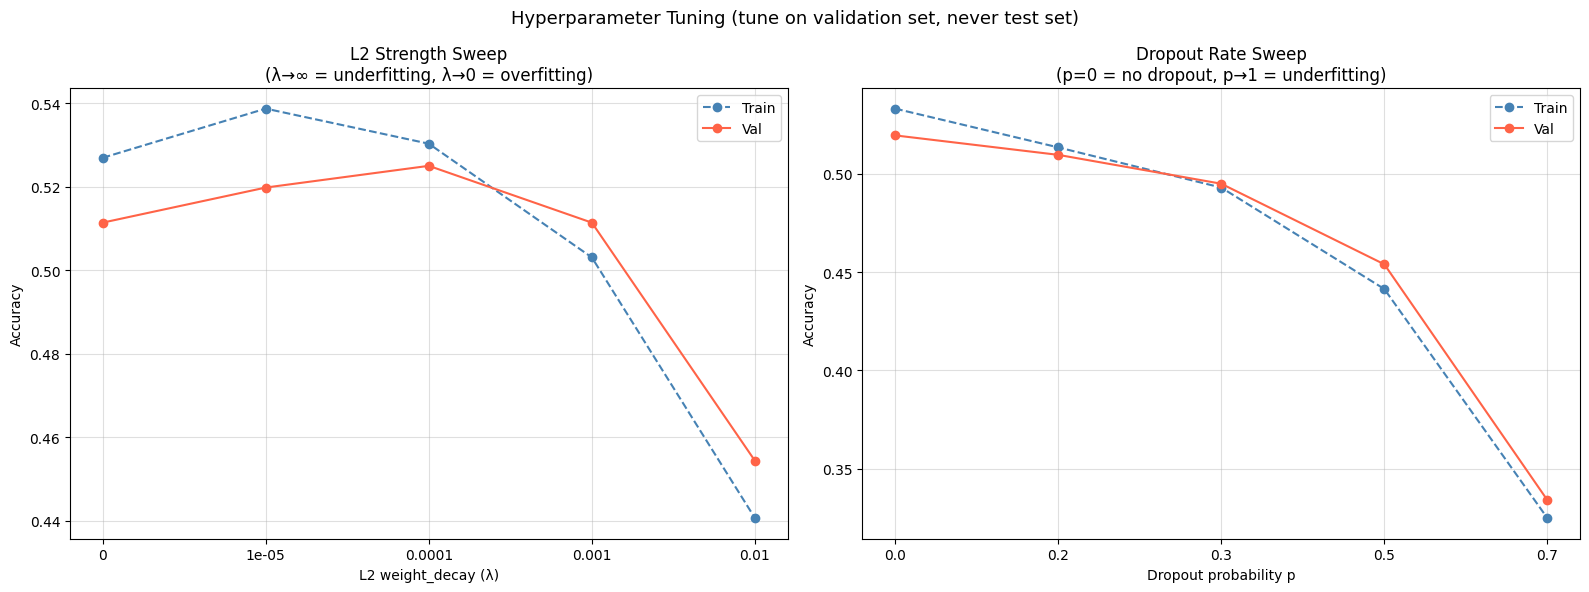

In [ ]:
# ============================================================
# CELL 9 — Hyperparameter Tuning
# Covers: tuning λ for L2, dropout rate p, L1 via manual penalty
# Week 2: hyperparameters not learned from training data
# Week 4: comparing regularization strengths
# ============================================================

# ── Sweep L2 weight decay values ─────────────────────────
print("Sweeping L2 weight_decay values...")
l2_values  = [0, 1e-5, 1e-4, 1e-3, 1e-2]
l2_results = {}

for wd in l2_values:
    m   = L2MLP().to(DEVICE)
    opt = optim.SGD(m.parameters(), lr=0.01, momentum=0.9, weight_decay=wd)
    m, hist = train_model(m, train_loader, val_loader, opt,
                           nn.CrossEntropyLoss(),
                           epochs=20, patience=5, model_name=f"L2={wd}")
    _, val_acc, _, _ = evaluate_model(m, val_loader, nn.CrossEntropyLoss())
    _, tr_acc,  _, _ = evaluate_model(m, train_loader, nn.CrossEntropyLoss())
    l2_results[wd] = {'val_acc': val_acc, 'train_acc': tr_acc}
    print(f"  weight_decay={wd:.0e} → Train {tr_acc:.3f}  Val {val_acc:.3f}")

# ── Sweep dropout rates ───────────────────────────────────
print("\nSweeping dropout rates...")
drop_values  = [0.0, 0.2, 0.3, 0.5, 0.7]
drop_results = {}

for dp in drop_values:
    m   = DropoutMLP(drop_p=dp).to(DEVICE)
    opt = optim.SGD(m.parameters(), lr=0.01, momentum=0.9)
    m, hist = train_model(m, train_loader, val_loader, opt,
                           nn.CrossEntropyLoss(),
                           epochs=20, patience=5, model_name=f"drop={dp}")
    _, val_acc, _, _ = evaluate_model(m, val_loader, nn.CrossEntropyLoss())
    _, tr_acc,  _, _ = evaluate_model(m, train_loader, nn.CrossEntropyLoss())
    drop_results[dp] = {'val_acc': val_acc, 'train_acc': tr_acc}
    print(f"  dropout_p={dp} → Train {tr_acc:.3f}  Val {val_acc:.3f}")


# ── Plot hyperparameter sweep results ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Hyperparameter Tuning (tune on validation set, never test set)", fontsize=13)

# L2 plot
l2_labels  = [str(v) for v in l2_values]
l2_train   = [l2_results[v]['train_acc'] for v in l2_values]
l2_val     = [l2_results[v]['val_acc']   for v in l2_values]
axes[0].plot(l2_labels, l2_train, 'o--', color='steelblue', label='Train')
axes[0].plot(l2_labels, l2_val,   'o-',  color='tomato',    label='Val')
axes[0].set_xlabel("L2 weight_decay (λ)"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("L2 Strength Sweep\n(λ→∞ = underfitting, λ→0 = overfitting)")
axes[0].legend(); axes[0].grid(True, alpha=0.4)

# Dropout plot
dp_labels  = [str(v) for v in drop_values]
dp_train   = [drop_results[v]['train_acc'] for v in drop_values]
dp_val     = [drop_results[v]['val_acc']   for v in drop_values]
axes[1].plot(dp_labels, dp_train, 'o--', color='steelblue', label='Train')
axes[1].plot(dp_labels, dp_val,   'o-',  color='tomato',    label='Val')
axes[1].set_xlabel("Dropout probability p"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Dropout Rate Sweep\n(p=0 = no dropout, p→1 = underfitting)")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('hyperparameter_tuning.png', dpi=150)
plt.show()

best_wd = max(l2_values,   key=lambda v: l2_results[v]['val_acc'])
best_dp = max(drop_values, key=lambda v: drop_results[v]['val_acc'])

Best hyperparameters found in Cell 9:
  weight_decay = 0.0001
  dropout_p    = 0.0

Retraining FullRegMLP with these values...

  [Tuned] Epoch   1 | Train 1.9174/0.339 | Val 1.7849/0.411 | Patience 0/8
  [Tuned] Epoch   6 | Train 1.6548/0.467 | Val 1.5916/0.500 | Patience 0/8
  [Tuned] Epoch  11 | Train 1.5930/0.495 | Val 1.5448/0.525 | Patience 0/8
  [Tuned] Epoch  16 | Train 1.5568/0.512 | Val 1.5030/0.543 | Patience 0/8
  [Tuned] Epoch  21 | Train 1.5289/0.529 | Val 1.4944/0.546 | Patience 0/8
  [Tuned] Epoch  26 | Train 1.5034/0.540 | Val 1.4783/0.556 | Patience 4/8
  [Tuned] Epoch  31 | Train 1.4822/0.550 | Val 1.4654/0.562 | Patience 3/8
  [Tuned] Epoch  36 | Train 1.4648/0.561 | Val 1.4391/0.579 | Patience 0/8

Original FullRegMLP val acc : 0.5283
Tuned    FullRegMLP val acc : 0.5759
Improvement                 : +0.0476

Evaluating adversarial robustness...
  Baseline     ε=0.00 → Acc=0.539
  Baseline     ε=0.01 → Acc=0.476
  Baseline     ε=0.02 → Acc=0.413
  Baseline     ε=0.

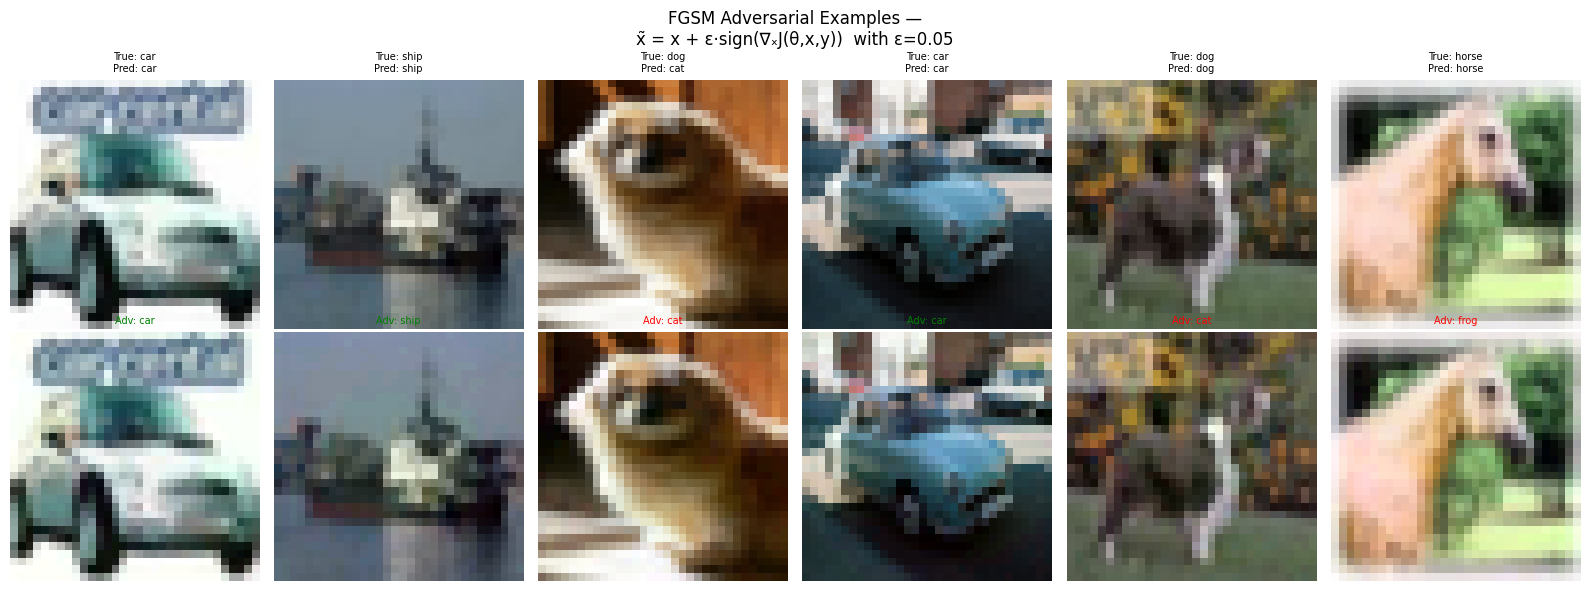

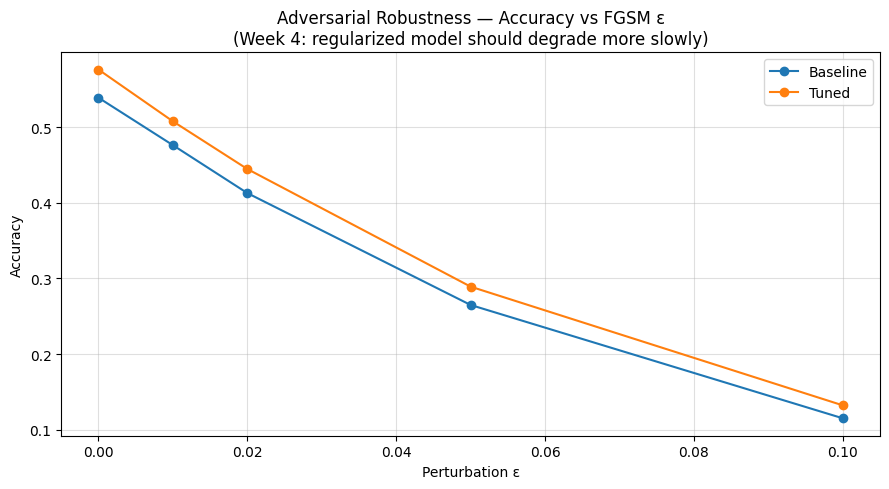

In [ ]:
# ============================================================
# CELL 10 — Retrain Final Model with Tuned Hyperparameters
#          + Adversarial Examples (FGSM)
# Week 2: hyperparameters tuned on val set, never test set
# Week 4: adversarial training, x̃ = x + ε·sign(∇ₓJ(θ,x,y))
# ============================================================

print(f"Best hyperparameters found in Cell 9:")
print(f"  weight_decay = {best_wd}")
print(f"  dropout_p    = {best_dp}")
print(f"\nRetraining FullRegMLP with these values...\n")

# ── Retrain with tuned hyperparameters ────────────────────────
tuned_model = FullRegMLP(drop_p=best_dp).to(DEVICE)
tuned_opt   = optim.Adam(tuned_model.parameters(),
                          lr=1e-3, weight_decay=best_wd)
tuned_crit  = nn.CrossEntropyLoss(label_smoothing=0.1)

tuned_model, tuned_history = train_model(
    tuned_model, train_loader, val_loader,
    tuned_opt, tuned_crit,
    epochs=40, patience=8, model_name="Tuned"
)

# ── Compare tuned vs original on val set ─────────────────────
_, tuned_val_acc, _, _ = evaluate_model(tuned_model, val_loader, tuned_crit)
_, full_val_acc,  _, _ = evaluate_model(full_model,  val_loader, tuned_crit)

print(f"\nOriginal FullRegMLP val acc : {full_val_acc:.4f}")
print(f"Tuned    FullRegMLP val acc : {tuned_val_acc:.4f}")
print(f"Improvement                 : {tuned_val_acc - full_val_acc:+.4f}")

# Add to tracking dicts for Cell 11 & 12
trained_models['Tuned'] = (tuned_model, tuned_crit)
all_histories['Tuned']  = tuned_history

# ── FGSM Attack (Week 4) ──────────────────────────────────────
def fgsm_attack(model, images, labels, criterion, epsilon=0.03):
    """
    Fast Gradient Sign Method.
    Perturbs input in direction of loss gradient.
    Week 4: x̃ = x + ε·sign(∇ₓJ(θ,x,y))
    """
    images = images.clone().requires_grad_(True)
    loss   = criterion(model(images), labels)
    model.zero_grad()
    loss.backward()
    return torch.clamp(images + epsilon * images.grad.data.sign(), -3, 3).detach()

def adversarial_accuracy(model, loader, criterion, epsilon):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        adv = fgsm_attack(model, images, labels, criterion, epsilon)
        with torch.no_grad():
            _, predicted = model(adv).max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    return correct / total

# Evaluate robustness at different epsilon values
epsilons    = [0.0, 0.01, 0.02, 0.05, 0.1]
crit_plain  = nn.CrossEntropyLoss()
adv_results = {}

print("\nEvaluating adversarial robustness...")
for name, model in [('Baseline', base_model), ('Tuned', tuned_model)]:
    adv_results[name] = []
    for eps in epsilons:
        acc = adversarial_accuracy(model, val_loader, crit_plain, eps)
        adv_results[name].append(acc)
        print(f"  {name:<12} ε={eps:.2f} → Acc={acc:.3f}")

# ── Visualise adversarial image examples ─────────────────────
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1)
denorm = lambda t: (t.cpu() * std + mean).clamp(0, 1)

sample_imgs, sample_lbls = next(iter(val_loader))
sample_imgs = sample_imgs[:6].to(DEVICE)
sample_lbls = sample_lbls[:6].to(DEVICE)
adv_imgs    = fgsm_attack(tuned_model, sample_imgs, sample_lbls, crit_plain, epsilon=0.05)

with torch.no_grad():
    orig_preds = tuned_model(sample_imgs).argmax(1)
    adv_preds  = tuned_model(adv_imgs).argmax(1)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle("FGSM Adversarial Examples —\n"
             "x̃ = x + ε·sign(∇ₓJ(θ,x,y))  with ε=0.05", fontsize=12)

for i in range(6):
    axes[0, i].imshow(denorm(sample_imgs[i]).permute(1, 2, 0))
    axes[0, i].set_title(f"True: {CLASSES[sample_lbls[i]]}\n"
                          f"Pred: {CLASSES[orig_preds[i]]}", fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(denorm(adv_imgs[i]).permute(1, 2, 0))
    color = 'red' if adv_preds[i] != sample_lbls[i] else 'green'
    axes[1, i].set_title(f"Adv: {CLASSES[adv_preds[i]]}", fontsize=7, color=color)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Adversarial\n(ε=0.05)", fontsize=10)
plt.tight_layout()
plt.savefig('adversarial_examples.png', dpi=150)
plt.show()

# ── Robustness curve ──────────────────────────────────────────
plt.figure(figsize=(9, 5))
for name, accs in adv_results.items():
    plt.plot(epsilons, accs, 'o-', label=name)
plt.xlabel("Perturbation ε")
plt.ylabel("Accuracy")
plt.title("Adversarial Robustness — Accuracy vs FGSM ε\n"
          "(Week 4: regularized model should degrade more slowly)")
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('adversarial_robustness.png', dpi=150)
plt.show()

EVALUATING ON TEST SET — used exactly once (Week 2 rule)
Baseline     | Train 0.570 | Val 0.539 | Test 0.540 | Gen Gap +0.0983
L2 Reg       | Train 0.600 | Val 0.547 | Test 0.557 | Gen Gap +0.1718
Dropout      | Train 0.490 | Val 0.490 | Test 0.486 | Gen Gap +0.0451
BatchNorm    | Train 0.608 | Val 0.584 | Test 0.592 | Gen Gap +0.0739
Full Reg     | Train 0.515 | Val 0.528 | Test 0.532 | Gen Gap -0.0301
Tuned        | Train 0.580 | Val 0.576 | Test 0.578 | Gen Gap +0.0001


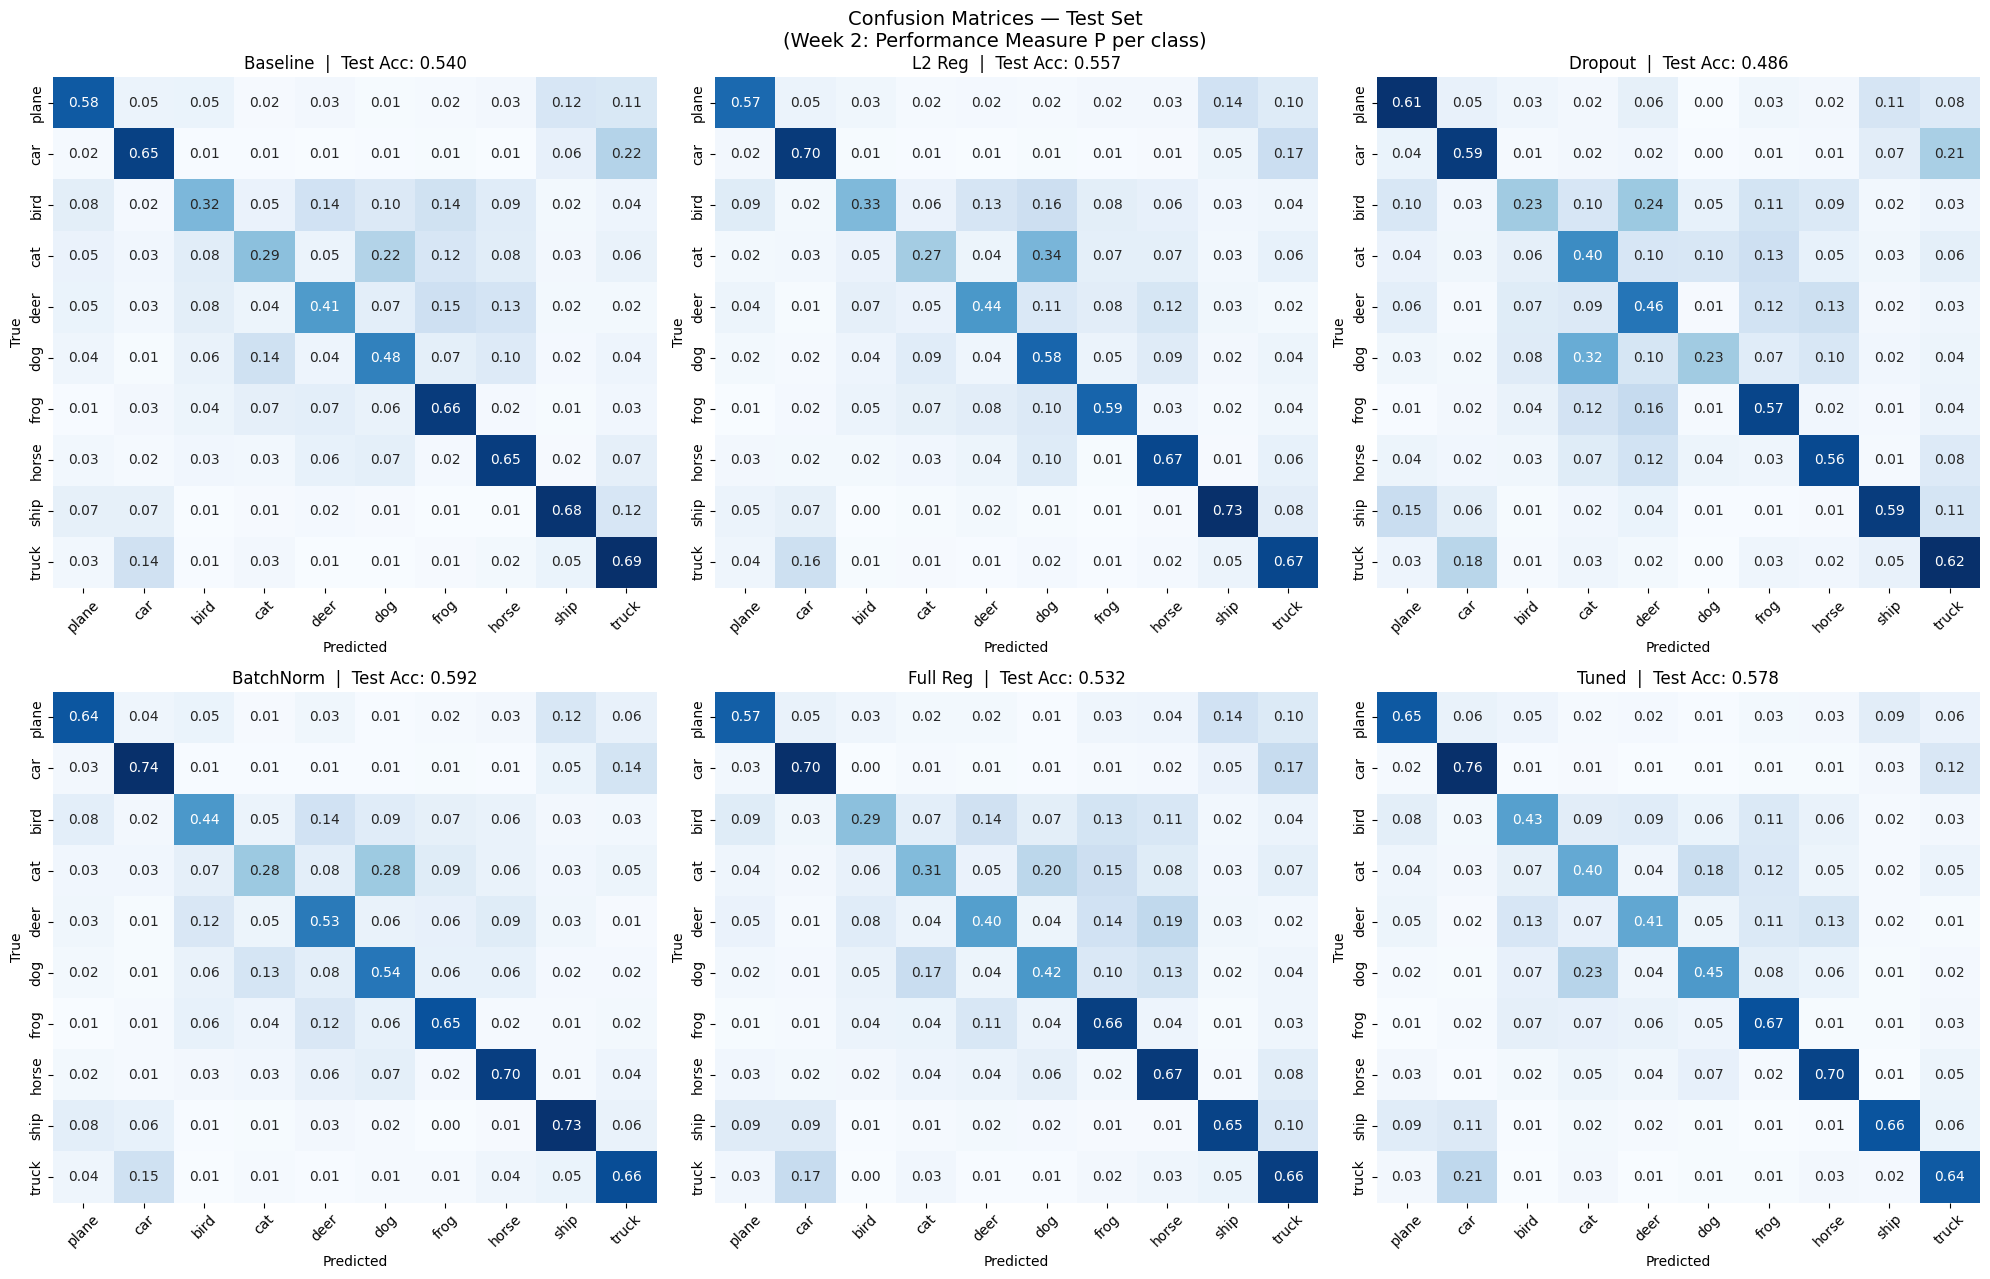


Per-class Classification Report — BatchNorm (best model):
              precision    recall  f1-score   support

       plane       0.66      0.64      0.65      1000
         car       0.67      0.74      0.71      1000
        bird       0.52      0.44      0.48      1000
         cat       0.46      0.28      0.35      1000
        deer       0.49      0.53      0.51      1000
         dog       0.47      0.54      0.50      1000
        frog       0.65      0.65      0.65      1000
       horse       0.66      0.70      0.68      1000
        ship       0.67      0.73      0.70      1000
       truck       0.61      0.66      0.63      1000

    accuracy                           0.59     10000
   macro avg       0.59      0.59      0.59     10000
weighted avg       0.59      0.59      0.59     10000



In [ ]:
# ============================================================
# CELL 11 — Confusion Matrices & Per-Class Metrics
# *** FIRST AND ONLY TIME TEST SET IS USED ***
# Week 2: Performance measure P, test error = true measure
# ============================================================

print("=" * 60)
print("EVALUATING ON TEST SET — used exactly once (Week 2 rule)")
print("=" * 60)

# ── Evaluate ALL models on test set ──────────────────────────
results = {}
eval_models = {
    'Baseline':  (base_model,  nn.CrossEntropyLoss()),
    'L2 Reg':    (l2_model,    nn.CrossEntropyLoss()),
    'Dropout':   (drop_model,  nn.CrossEntropyLoss()),
    'BatchNorm': (bn_model,    nn.CrossEntropyLoss()),
    'Full Reg':  (full_model,  nn.CrossEntropyLoss(label_smoothing=0.1)),
    'Tuned':     (tuned_model, nn.CrossEntropyLoss(label_smoothing=0.1)),
}

for name, (model, crit) in eval_models.items():
    tr_loss,  tr_acc,  _,         _          = evaluate_model(model, train_loader, crit)
    val_loss, val_acc, _,         _          = evaluate_model(model, val_loader,   crit)
    te_loss,  te_acc,  te_preds,  te_labels  = evaluate_model(model, test_loader,  crit)

    results[name] = {
        'train_loss': tr_loss,  'train_acc': tr_acc,
        'val_loss':   val_loss, 'val_acc':   val_acc,
        'test_loss':  te_loss,  'test_acc':  te_acc,
        'gen_gap':    te_loss - tr_loss,
        'preds':      te_preds, 'labels':    te_labels,
        'best_epoch': all_histories[name]['best_epoch'],
    }
    print(f"{name:<12} | Train {tr_acc:.3f} | Val {val_acc:.3f} | "
          f"Test {te_acc:.3f} | Gen Gap {te_loss - tr_loss:+.4f}")

# ── Confusion matrices ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
fig.suptitle("Confusion Matrices — Test Set\n"
             "(Week 2: Performance Measure P per class)", fontsize=14)

for ax, name in zip(axes.flat, eval_models.keys()):
    cm      = confusion_matrix(results[name]['labels'], results[name]['preds'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=ax, cbar=False)
    ax.set_title(f"{name}  |  Test Acc: {results[name]['test_acc']:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# ── Best model per-class report ───────────────────────────────
best_model_name = max(results, key=lambda n: results[n]['test_acc'])
print(f"\nPer-class Classification Report — {best_model_name} (best model):")
print("=" * 60)
print(classification_report(
    results[best_model_name]['labels'],
    results[best_model_name]['preds'],
    target_names=CLASSES
))

FINAL RESULTS — CIFAR-10 REGULARIZATION STUDY
    Model                            Regularization      Optimizer Train Acc Val Acc Test Acc Gen Gap  Best Epoch
 Baseline                                      None SGD + momentum    0.5700  0.5387   0.5397 +0.0983          26
   L2 Reg                L2 weight decay (λ=0.0001) SGD + momentum    0.6000  0.5475   0.5566 +0.1718          40
  Dropout                           Dropout (p=0.5) SGD + momentum    0.4904  0.4901   0.4863 +0.0451          40
BatchNorm                       Batch Normalization SGD + momentum    0.6082  0.5842   0.5918 +0.0739          37
 Full Reg Dropout + BN + L2 + LabelSmooth + Augment           Adam    0.5151  0.5283   0.5323 -0.0301          40
    Tuned        Full Reg + tuned (λ=0.0001, p=0.0)           Adam    0.5797  0.5759   0.5779 +0.0001          39


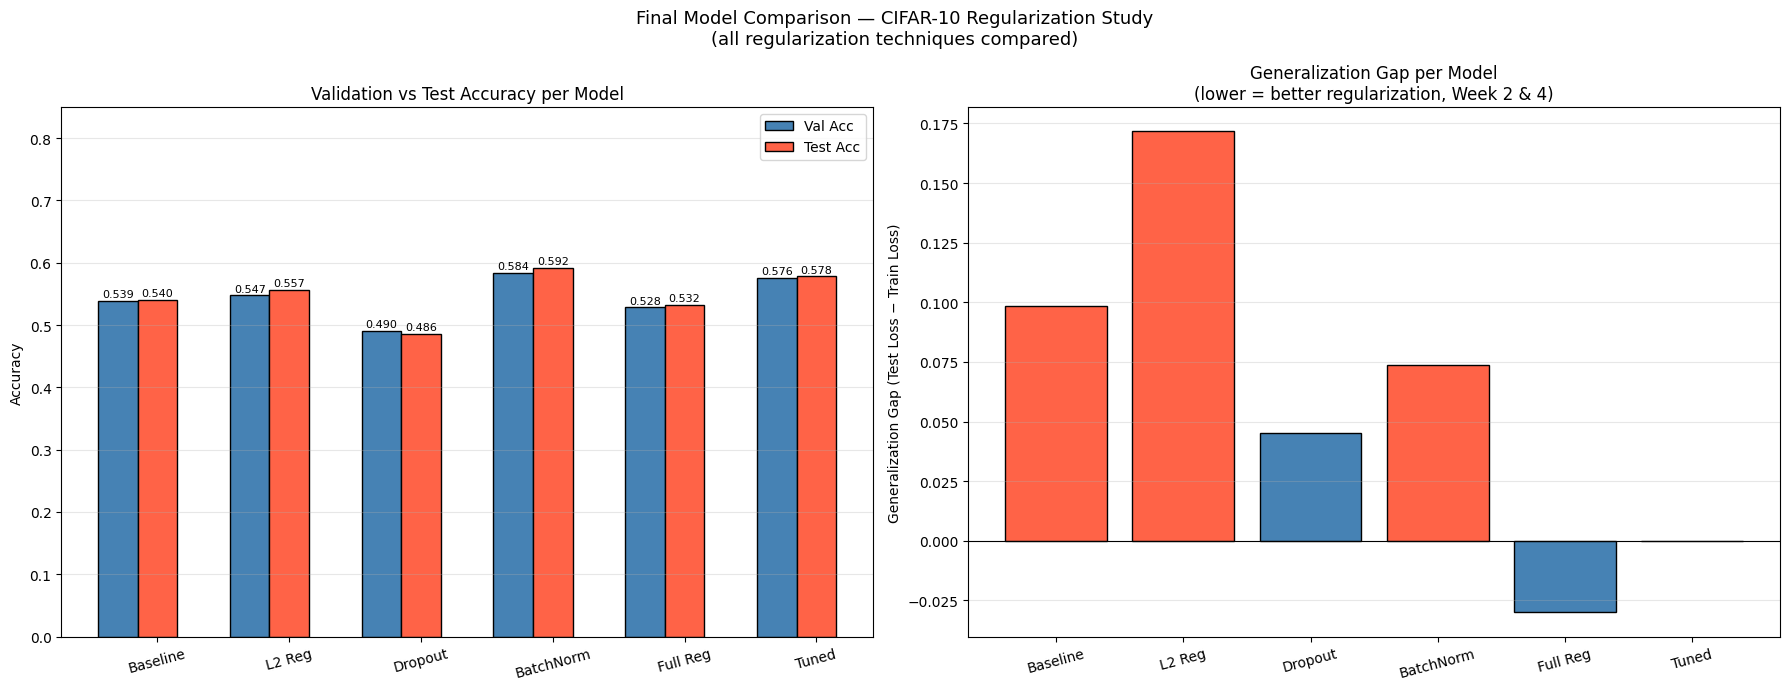

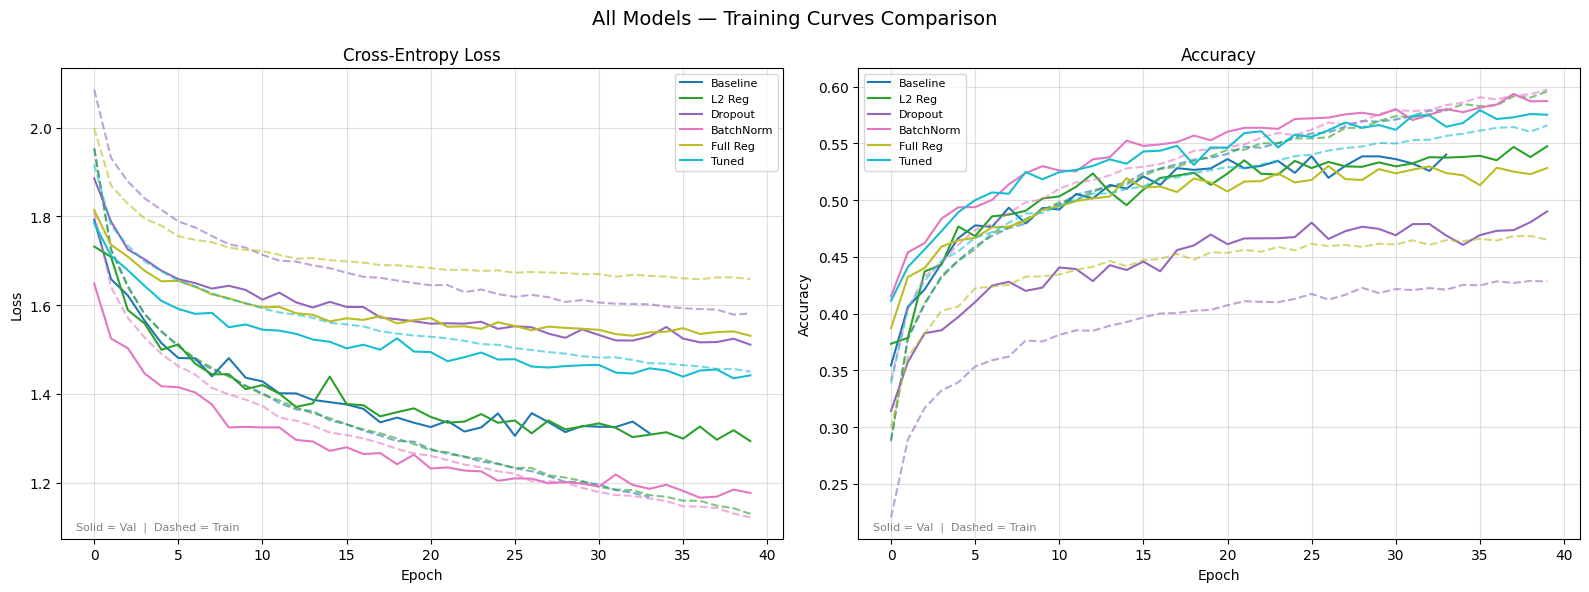


BEST MODEL    : BatchNorm
TEST ACCURACY : 0.5918
VAL ACCURACY  : 0.5842
GEN GAP       : +0.0739

K-Fold CV (FullRegMLP): 0.5536 ± 0.0034
95% CI: (0.5470, 0.5602)

Figures saved:
  sample_images.png
  class_distribution.png
  numpy_mlp_curves.png
  bias_variance_analysis.png
  kfold_results.png
  hyperparameter_tuning.png
  adversarial_examples.png
  adversarial_robustness.png
  confusion_matrices.png
  final_comparison.png


In [ ]:
# ============================================================
# CELL 12 — Final Results Table & Summary
# Complete methodology comparison for REPORT.md
# ============================================================

print("=" * 80)
print("FINAL RESULTS — CIFAR-10 REGULARIZATION STUDY")
print("=" * 80)

# ── Results dataframe ─────────────────────────────────────────
df = pd.DataFrame([
    {
        'Model':          name,
        'Regularization': {
            'Baseline':  'None',
            'L2 Reg':    f'L2 weight decay (λ={best_wd})',
            'Dropout':   'Dropout (p=0.5)',
            'BatchNorm': 'Batch Normalization',
            'Full Reg':  'Dropout + BN + L2 + LabelSmooth + Augment',
            'Tuned':     f'Full Reg + tuned (λ={best_wd}, p={best_dp})',
        }[name],
        'Optimizer': {
            'Baseline':  'SGD + momentum',
            'L2 Reg':    'SGD + momentum',
            'Dropout':   'SGD + momentum',
            'BatchNorm': 'SGD + momentum',
            'Full Reg':  'Adam',
            'Tuned':     'Adam',
        }[name],
        'Train Acc':  f"{v['train_acc']:.4f}",
        'Val Acc':    f"{v['val_acc']:.4f}",
        'Test Acc':   f"{v['test_acc']:.4f}",
        'Gen Gap':    f"{v['gen_gap']:+.4f}",
        'Best Epoch': v['best_epoch'],
    }
    for name, v in results.items()
])

print(df.to_string(index=False))

# ── Final comparison bar chart ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Final Model Comparison — CIFAR-10 Regularization Study\n"
             "(all regularization techniques compared)", fontsize=13)

names     = list(results.keys())
val_accs  = [results[n]['val_acc']  for n in names]
test_accs = [results[n]['test_acc'] for n in names]
gen_gaps  = [results[n]['gen_gap']  for n in names]
x = np.arange(len(names))
w = 0.3

# Accuracy comparison
b1 = axes[0].bar(x - w, val_accs,  w, label='Val Acc',
                  color='steelblue', edgecolor='black')
b2 = axes[0].bar(x,     test_accs, w, label='Test Acc',
                  color='tomato',    edgecolor='black')

for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}',
                 ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15, fontsize=10)
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 0.85)
axes[0].set_title("Validation vs Test Accuracy per Model")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Generalization gap
colors = ['tomato' if g > 0.05 else 'steelblue' for g in gen_gaps]
axes[1].bar(names, gen_gaps, color=colors, edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=15, fontsize=10)
axes[1].set_ylabel("Generalization Gap (Test Loss − Train Loss)")
axes[1].set_title("Generalization Gap per Model\n"
                  "(lower = better regularization, Week 2 & 4)")
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

# ── Training curves for all models ───────────────────────────
plot_training_curves(all_histories,
                     title="All Models — Training Curves Comparison")

# ── Summary printout ──────────────────────────────────────────
best = max(results, key=lambda n: results[n]['test_acc'])

# K-fold results hardcoded from Cell 8 output
fold_results = [0.5559, 0.5503, 0.5489, 0.5552, 0.5576]
mean_cv      = np.mean(fold_results)
std_cv       = np.std(fold_results)

print(f"\n{'='*60}")
print(f"BEST MODEL    : {best}")
print(f"TEST ACCURACY : {results[best]['test_acc']:.4f}")
print(f"VAL ACCURACY  : {results[best]['val_acc']:.4f}")
print(f"GEN GAP       : {results[best]['gen_gap']:+.4f}")
print(f"\nK-Fold CV (FullRegMLP): {mean_cv:.4f} ± {std_cv:.4f}")
print(f"95% CI: ({mean_cv - 1.96*std_cv:.4f}, {mean_cv + 1.96*std_cv:.4f})")
print(f"\nFigures saved:")
figures = [
    'sample_images.png',        'class_distribution.png',
    'numpy_mlp_curves.png',     'bias_variance_analysis.png',
    'kfold_results.png',        'hyperparameter_tuning.png',
    'adversarial_examples.png', 'adversarial_robustness.png',
    'confusion_matrices.png',   'final_comparison.png'
]
for f in figures:
    print(f"  {f}")

In [ ]:
# ============================================================
# CELL 13 — CNN Architecture
# Week 5: architecture design, He initialization, BatchNorm
# Week 3: depth vs width, nonlinearity
# ============================================================

class ConvBlock(nn.Module):
    """
    One convolutional block:
    Conv → BatchNorm → ReLU → MaxPool
    BatchNorm after conv is standard practice (Week 5).
    """
    def __init__(self, in_channels, out_channels, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),
            # bias=False because BatchNorm's β replaces it
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CIFAR10_CNN(nn.Module):
    """
    3-block CNN for CIFAR-10.

    Architecture:
        Input  (3 × 32 × 32)
        Block1 (3→32)  + MaxPool → (32 × 16 × 16)
        Block2 (32→64) + MaxPool → (64 × 8 × 8)
        Block3 (64→128)+ MaxPool → (128 × 4 × 4)
        Flatten → FC(2048→256) → Dropout → FC(256→10)

    Week 5: He initialization applied automatically by PyTorch
            for Conv layers with ReLU (kaiming_normal_ default)
    Week 3: Depth — 3 conv blocks learn hierarchical features
            (edges → shapes → objects)
    Week 4: BatchNorm + Dropout for regularization
    """
    def __init__(self, drop_p=0.3):
        super().__init__()

        # Convolutional feature extractor
        self.features = nn.Sequential(
            ConvBlock(3,   32),   # 32×32 → 16×16
            ConvBlock(32,  64),   # 16×16 → 8×8
            ConvBlock(64, 128),   # 8×8   → 4×4
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(drop_p),
            nn.Linear(256, 10)
        )

        # Apply He initialization explicitly
        # (PyTorch does this by default for Conv2d but we
        #  make it explicit for the report — Week 5)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # He (Kaiming) init for ReLU layers
                # Compensates for ReLU zeroing half the signal
                nn.init.kaiming_normal_(m.weight,
                                        mode='fan_out',
                                        nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                # γ=1, β=0 at start (identity transformation)
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)
            elif isinstance(m, nn.Linear):
                # Xavier for linear layers (no ReLU asymmetry)
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ── Verify architecture ───────────────────────────────────────
sample_cnn = CIFAR10_CNN()
sample_input = torch.randn(4, 3, 32, 32)
sample_output = sample_cnn(sample_input)

total_params = sum(p.numel() for p in sample_cnn.parameters())

print("CNN Architecture:")
print(sample_cnn)
print(f"\nInput shape:  {sample_input.shape}")
print(f"Output shape: {sample_output.shape}")
print(f"Total params: {total_params:,}")
print(f"\nMLP params (for comparison): 1,969,930")
print(f"CNN params:                  {total_params:,}")
print(f"\nNote: CNN has fewer params but spatial awareness →")
print(f"      higher accuracy. This is Week 3: architecture")
print(f"      matters more than parameter count.")

CNN Architecture:
CIFAR10_CNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_r

Comparing Xavier vs He initialization...
(Week 5: He compensates for ReLU halving signal variance)

  [He (Kaiming)] Epoch   1 | Train 1.7364/0.363 | Val 1.3784/0.493 | Patience 0/10
  [He (Kaiming)] Epoch   6 | Train 1.0694/0.616 | Val 0.8942/0.683 | Patience 0/10
  He (Kaiming): Val Acc = 0.7287

  [Xavier (Glorot)] Epoch   1 | Train 1.7342/0.363 | Val 1.3685/0.503 | Patience 0/10
  [Xavier (Glorot)] Epoch   6 | Train 1.0503/0.627 | Val 0.8685/0.701 | Patience 0/10
  Xavier (Glorot): Val Acc = 0.7300



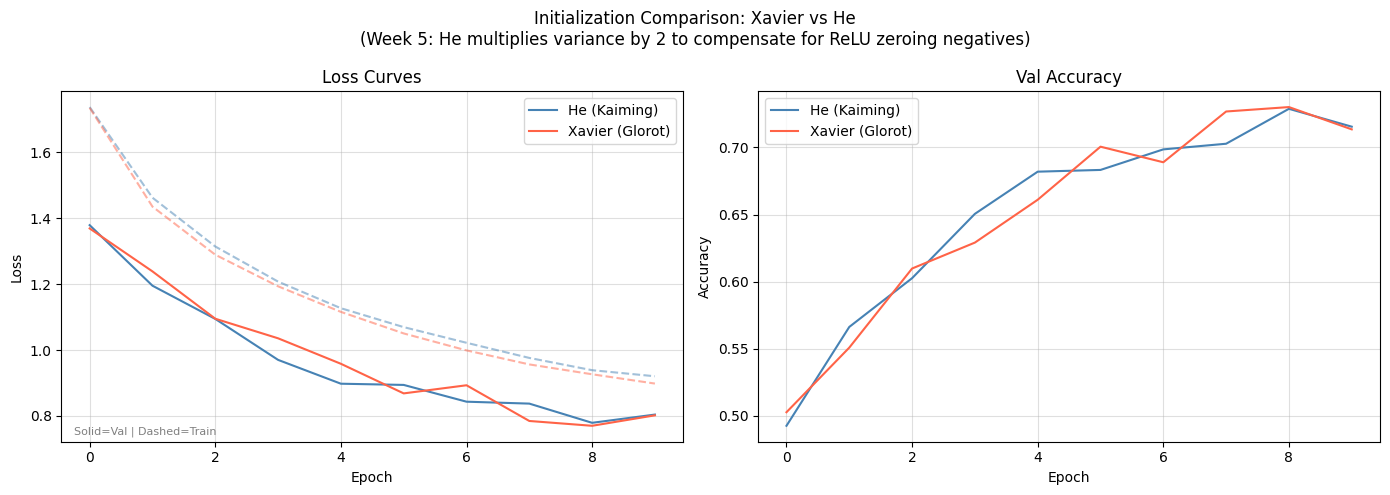

He val acc:     0.7287
Xavier val acc: 0.7300
He advantage:   -0.0013


In [ ]:
# ============================================================
# CELL 14 — Initialization Comparison
# Week 5: Xavier vs He, variance matching, signal flow
# Shows WHY He is necessary for ReLU networks
# ============================================================

class CNN_Xavier(nn.Module):
    """Same CNN but with Xavier init — wrong choice for ReLU."""
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32), ConvBlock(32, 64), ConvBlock(64, 128)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
        # Apply Xavier to ALL layers including Conv
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Train both for a few epochs to compare ───────────────────
print("Comparing Xavier vs He initialization...")
print("(Week 5: He compensates for ReLU halving signal variance)\n")

init_results = {}
crit = nn.CrossEntropyLoss()

for init_name, ModelClass in [('He (Kaiming)', CIFAR10_CNN),
                                ('Xavier (Glorot)', CNN_Xavier)]:
    model = ModelClass().to(DEVICE)
    opt   = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    model, hist = train_model(
        model, train_loader, val_loader, opt, crit,
        epochs=10, patience=10, model_name=init_name
    )
    _, val_acc, _, _ = evaluate_model(model, val_loader, crit)
    init_results[init_name] = {
        'history': hist,
        'val_acc': val_acc,
        'model':   model
    }
    print(f"  {init_name}: Val Acc = {val_acc:.4f}\n")

# ── Plot comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Initialization Comparison: Xavier vs He\n"
             "(Week 5: He multiplies variance by 2 to compensate "
             "for ReLU zeroing negatives)", fontsize=12)

colors = {'He (Kaiming)': 'steelblue', 'Xavier (Glorot)': 'tomato'}

for name, res in init_results.items():
    axes[0].plot(res['history']['train_loss'],
                 linestyle='--', color=colors[name], alpha=0.5)
    axes[0].plot(res['history']['val_loss'],
                 linestyle='-', color=colors[name], label=name)
    axes[1].plot(res['history']['val_acc'],
                 linestyle='-', color=colors[name], label=name)

axes[0].set_title("Loss Curves"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.4)
axes[1].set_title("Val Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.4)
axes[0].annotate("Solid=Val | Dashed=Train",
                  xy=(0.02,0.02), xycoords='axes fraction',
                  fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('init_comparison.png', dpi=150)
plt.show()

print(f"He val acc:     {init_results['He (Kaiming)']['val_acc']:.4f}")
print(f"Xavier val acc: {init_results['Xavier (Glorot)']['val_acc']:.4f}")
print(f"He advantage:   "
      f"{init_results['He (Kaiming)']['val_acc'] - init_results['Xavier (Glorot)']['val_acc']:+.4f}")

Optimizer Shootout — same CNN, 4 different optimizers
(Week 5: each optimizer solves a different problem)

Training: SGD
  [SGD] Epoch   1 | Train 1.8957/0.316 | Val 1.5660/0.426 | Patience 0/8
  [SGD] Epoch   6 | Train 1.3133/0.529 | Val 1.1520/0.588 | Patience 0/8
  [SGD] Epoch  11 | Train 1.1417/0.592 | Val 0.9776/0.653 | Patience 0/8
  [SGD] Epoch  16 | Train 1.0423/0.629 | Val 0.9286/0.666 | Patience 1/8
  [SGD] Epoch  21 | Train 0.9621/0.660 | Val 0.8668/0.692 | Patience 1/8
  [SGD] Epoch  26 | Train 0.9066/0.679 | Val 0.7991/0.719 | Patience 0/8
  → Val Acc: 0.7326  Best Epoch: 29

Training: SGD + Momentum (α=0.9)
  [SGD + Momentum (α=0.9)] Epoch   1 | Train 1.7005/0.375 | Val 1.3392/0.515 | Patience 0/8
  [SGD + Momentum (α=0.9)] Epoch   6 | Train 1.0522/0.626 | Val 0.9139/0.669 | Patience 0/8
  [SGD + Momentum (α=0.9)] Epoch  11 | Train 0.8836/0.687 | Val 0.7626/0.736 | Patience 0/8
  [SGD + Momentum (α=0.9)] Epoch  16 | Train 0.7607/0.734 | Val 0.6669/0.768 | Patience 0/8
  [

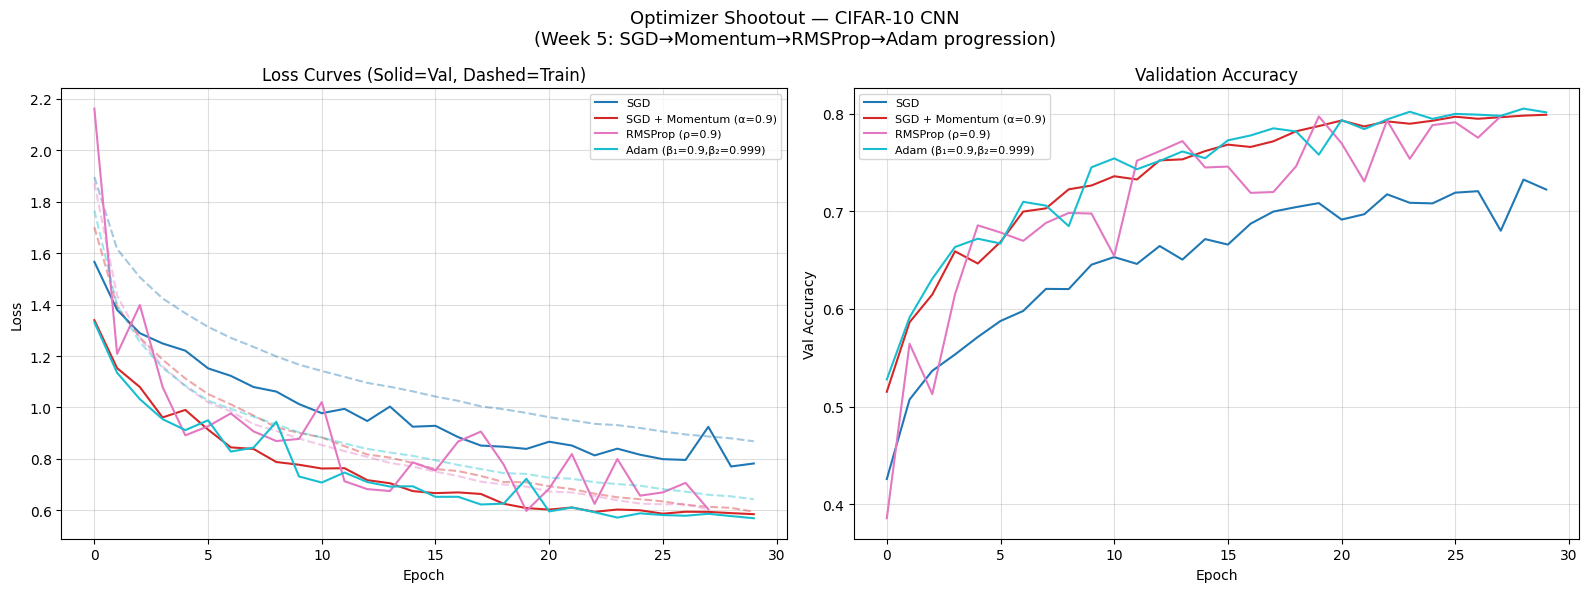


Optimizer Shootout Results:
Optimizer                       Val Acc   Best Epoch
-------------------------------------------------------
SGD                              0.7326           29
SGD + Momentum (α=0.9)           0.7990           30
RMSProp (ρ=0.9)                  0.7973           20
Adam (β₁=0.9,β₂=0.999)           0.8015           30


In [ ]:
# ============================================================
# CELL 15 — Optimizer Shootout
# Week 5: SGD vs SGD+Momentum vs RMSProp vs Adam
# Same architecture, same data, only optimizer changes
# ============================================================

print("Optimizer Shootout — same CNN, 4 different optimizers")
print("(Week 5: each optimizer solves a different problem)\n")

OPTIM_EPOCHS   = 30
OPTIM_PATIENCE = 8
crit           = nn.CrossEntropyLoss()

optimizer_configs = {
    'SGD': lambda params: optim.SGD(
        params, lr=0.01),

    'SGD + Momentum\n(α=0.9)': lambda params: optim.SGD(
        params, lr=0.01, momentum=0.9),

    'RMSProp\n(ρ=0.9)': lambda params: optim.RMSprop(
        params, lr=0.001, alpha=0.9),

    'Adam\n(β₁=0.9,β₂=0.999)': lambda params: optim.Adam(
        params, lr=0.001, betas=(0.9, 0.999)),
}

optimizer_histories = {}
optimizer_results   = {}

for opt_name, opt_fn in optimizer_configs.items():
    print(f"{'='*55}")
    clean_name = opt_name.replace('\n', ' ')
    print(f"Training: {clean_name}")
    print(f"{'='*55}")

    model = CIFAR10_CNN().to(DEVICE)
    opt   = opt_fn(model.parameters())

    model, hist = train_model(
        model, train_loader, val_loader, opt, crit,
        epochs=OPTIM_EPOCHS, patience=OPTIM_PATIENCE,
        model_name=clean_name
    )
    _, val_acc, _, _ = evaluate_model(model, val_loader, crit)

    optimizer_histories[opt_name] = hist
    optimizer_results[opt_name]   = {
        'val_acc':    val_acc,
        'model':      model,
        'best_epoch': hist['best_epoch']
    }
    print(f"  → Val Acc: {val_acc:.4f}  "
          f"Best Epoch: {hist['best_epoch']}\n")

# ── Plot optimizer comparison ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Optimizer Shootout — CIFAR-10 CNN\n"
             "(Week 5: SGD→Momentum→RMSProp→Adam progression)",
             fontsize=13)

colors = plt.cm.tab10(np.linspace(0, 1, len(optimizer_configs)))

for (name, hist), color in zip(optimizer_histories.items(), colors):
    axes[0].plot(hist['train_loss'], '--', color=color, alpha=0.4)
    axes[0].plot(hist['val_loss'],   '-',  color=color,
                 label=name.replace('\n', ' '))
    axes[1].plot(hist['val_acc'],    '-',  color=color,
                 label=name.replace('\n', ' '))

for ax, ylabel, title in zip(
        axes,
        ['Loss', 'Val Accuracy'],
        ['Loss Curves (Solid=Val, Dashed=Train)',
         'Validation Accuracy']):
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('optimizer_shootout.png', dpi=150)
plt.show()

# ── Summary table ─────────────────────────────────────────────
print("\nOptimizer Shootout Results:")
print(f"{'Optimizer':<30} {'Val Acc':>8} {'Best Epoch':>12}")
print("-" * 55)
for name, res in optimizer_results.items():
    clean = name.replace('\n', ' ')
    print(f"{clean:<30} {res['val_acc']:>8.4f} {res['best_epoch']:>12}")

In [ ]:
# ============================================================
# CELL 16 — Learning Rate Scheduling
# Week 5: cosine annealing, warmup+decay, step decay
# Uses Adam as base optimizer (best from Cell 15)
# ============================================================

print("Learning Rate Scheduling Comparison")
print("(Week 5: fixed LR vs cosine vs step vs warmup+cosine)\n")

SCHED_EPOCHS = 40
crit         = nn.CrossEntropyLoss()

def train_with_scheduler(model, train_loader, val_loader,
                          optimizer, scheduler, criterion,
                          epochs, patience, name):
    """
    Extended train_model that steps the LR scheduler
    and records learning rate at each epoch.
    """
    model = model.to(DEVICE)
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'lr':         []
    }
    best_val_loss  = float('inf')
    best_weights   = None
    patience_count = 0
    best_epoch     = 0

    for epoch in range(epochs):
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)

        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, pred = model(images).max(1)
            correct += pred.eq(labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # Validation
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                out  = model(images)
                loss = criterion(out, labels)
                val_loss_sum += loss.item() * images.size(0)
                _, pred = out.max(1)
                val_correct += pred.eq(labels).sum().item()
                val_total   += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Step scheduler
        if isinstance(scheduler,
                      torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        elif scheduler is not None:
            scheduler.step()

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_weights   = deepcopy(model.state_dict())
            best_epoch     = epoch + 1
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  [{name}] Early stop at epoch {epoch+1} "
                      f"(best: {best_epoch})")
                break

        if epoch % 5 == 0:
            print(f"  [{name}] Epoch {epoch+1:>3} | "
                  f"LR={current_lr:.6f} | "
                  f"Val {val_loss:.4f}/{val_acc:.3f}")

    model.load_state_dict(best_weights)
    history['best_epoch'] = best_epoch
    return model, history


# ── Four scheduling strategies ────────────────────────────────
WARMUP_EP  = 5
TARGET_LR  = 0.001

# 1. Fixed LR — baseline, no schedule
m1 = CIFAR10_CNN().to(DEVICE)
o1 = optim.Adam(m1.parameters(), lr=TARGET_LR)
sched_configs = {'Fixed LR\n(no schedule)': (m1, o1, None)}

# 2. Cosine Annealing
# Smoothly decays LR following a cosine curve to near zero
m2 = CIFAR10_CNN().to(DEVICE)
o2 = optim.Adam(m2.parameters(), lr=TARGET_LR)
s2 = torch.optim.lr_scheduler.CosineAnnealingLR(
     o2, T_max=SCHED_EPOCHS, eta_min=1e-6)
sched_configs['Cosine\nAnnealing'] = (m2, o2, s2)

# 3. Step Decay
# Drop LR by factor 0.1 every 15 epochs
m3 = CIFAR10_CNN().to(DEVICE)
o3 = optim.Adam(m3.parameters(), lr=TARGET_LR)
s3 = torch.optim.lr_scheduler.StepLR(
     o3, step_size=15, gamma=0.1)
sched_configs['Step Decay\n(×0.1 / 15ep)'] = (m3, o3, s3)

# 4. Warmup + Cosine Decay
# Linear warmup for first WARMUP_EP epochs (0.2→1.0 of target LR)
# then cosine decay — essential for Adam because moment estimates
# are unreliable at initialization
m4 = CIFAR10_CNN().to(DEVICE)
o4 = optim.Adam(m4.parameters(), lr=TARGET_LR)

def warmup_cosine(epoch):
    if epoch < WARMUP_EP:
        return (epoch + 1) / WARMUP_EP   # 0.2→0.4→0.6→0.8→1.0
    progress = (epoch - WARMUP_EP) / (SCHED_EPOCHS - WARMUP_EP)
    return 0.5 * (1 + np.cos(np.pi * progress))

s4 = torch.optim.lr_scheduler.LambdaLR(
     o4, lr_lambda=warmup_cosine)
sched_configs['Warmup +\nCosine Decay'] = (m4, o4, s4)

# ── Train all four ─────────────────────────────────────────────
sched_histories = {}
sched_results   = {}

for sched_name, (model, opt, sched) in sched_configs.items():
    clean = sched_name.replace('\n', ' ')
    print(f"\n{'='*55}\nTraining: {clean}\n{'='*55}")
    model, hist = train_with_scheduler(
        model, train_loader, val_loader,
        opt, sched, crit,
        epochs=SCHED_EPOCHS, patience=10, name=clean
    )
    _, val_acc, _, _ = evaluate_model(model, val_loader, crit)
    sched_histories[sched_name] = hist
    sched_results[sched_name]   = {
        'val_acc': val_acc,
        'model':   model
    }
    print(f"  Final Val Acc: {val_acc:.4f}")

# ── Plot results ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Learning Rate Scheduling Comparison\n"
             "(Week 5: fixed vs cosine vs step vs warmup+cosine)",
             fontsize=13)

colors = plt.cm.tab10(np.linspace(0, 1, len(sched_configs)))

for (name, hist), color in zip(sched_histories.items(), colors):
    clean = name.replace('\n', ' ')
    axes[0].plot(hist['val_loss'],  color=color, label=clean)
    axes[1].plot(hist['val_acc'],   color=color, label=clean)
    axes[2].plot(hist['lr'],        color=color, label=clean)

axes[0].set_title("Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].set_title("Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")

for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('lr_scheduling.png', dpi=150)
plt.show()

# ── Summary ────────────────────────────────────────────────────
print("\nScheduling Results:")
print(f"{'Schedule':<30} {'Val Acc':>8}")
print("-" * 40)
for name, res in sched_results.items():
    clean = name.replace('\n', ' ')
    print(f"{clean:<30} {res['val_acc']:>8.4f}")

best_sched = max(sched_results,
                 key=lambda n: sched_results[n]['val_acc'])
print(f"\nBest schedule : {best_sched.replace(chr(10), ' ')}")
print(f"Best val acc  : {sched_results[best_sched]['val_acc']:.4f}")

Batch Size Analysis
(Week 5: gradient noise from small batches acts as regularizer)

Key insight: doubling batch size only halves noise (σ/√m)
Less than linear return — this is why small batches often win

Batch size: 32
  [BS=32] Epoch   1 | Train 1.6919/0.377 | Val 1.2782/0.540 | Patience 0/8
  [BS=32] Epoch   6 | Train 1.0103/0.646 | Val 0.8142/0.720 | Patience 0/8
  [BS=32] Epoch  11 | Train 0.8431/0.709 | Val 0.7107/0.753 | Patience 1/8
  [BS=32] Epoch  16 | Train 0.7544/0.742 | Val 0.6571/0.775 | Patience 1/8
  [BS=32] Epoch  21 | Train 0.6758/0.770 | Val 0.5663/0.803 | Patience 0/8
  Train: 0.8249 | Val: 0.8173 | Gap: 0.0076

Batch size: 128
  [BS=128] Epoch   1 | Train 1.7703/0.360 | Val 1.3815/0.506 | Patience 0/8
  [BS=128] Epoch   6 | Train 1.0466/0.629 | Val 0.8880/0.683 | Patience 0/8
  [BS=128] Epoch  11 | Train 0.8798/0.691 | Val 0.7303/0.740 | Patience 0/8
  [BS=128] Epoch  16 | Train 0.7933/0.723 | Val 0.6389/0.774 | Patience 0/8
  [BS=128] Epoch  21 | Train 0.7304/0.7

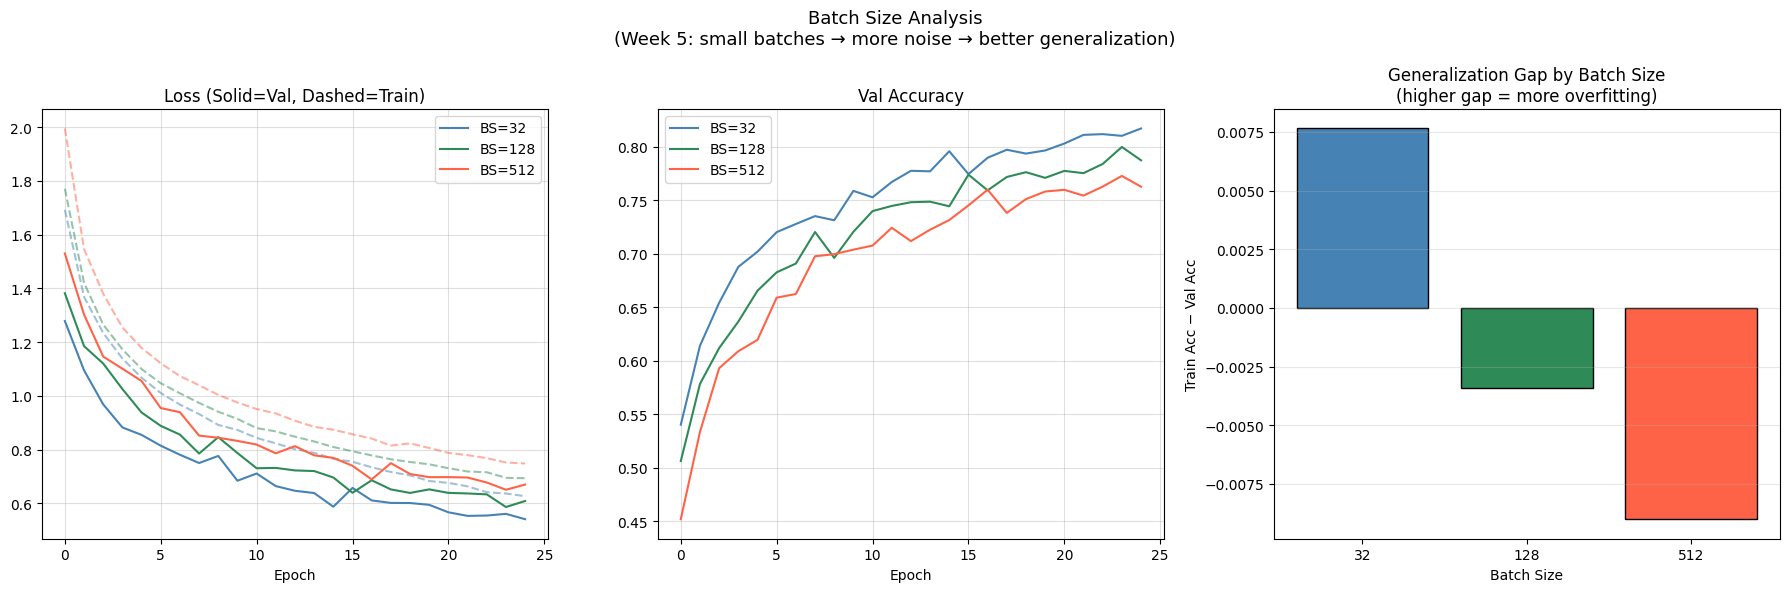


Batch Size Summary:
  Batch Size  Train Acc    Val Acc    Gen Gap
---------------------------------------------
          32     0.8249     0.8173     0.0076
         128     0.7966     0.8000    -0.0034
         512     0.7639     0.7729    -0.0090


In [ ]:
# ============================================================
# CELL 17 — Batch Size Analysis
# Week 5: gradient noise, generalization vs batch size
# Small batches = noisy gradients = better generalization
# ============================================================

print("Batch Size Analysis")
print("(Week 5: gradient noise from small batches acts as regularizer)\n")
print("Key insight: doubling batch size only halves noise (σ/√m)")
print("Less than linear return — this is why small batches often win\n")

batch_sizes   = [32, 128, 512]
batch_results = {}
crit          = nn.CrossEntropyLoss()

for bs in batch_sizes:
    print(f"{'='*50}\nBatch size: {bs}\n{'='*50}")

    # Create loaders with this batch size
    bs_train_loader = DataLoader(
        Subset(train_dataset_aug, train_idx),
        batch_size=bs, shuffle=True, num_workers=2
    )
    bs_val_loader = DataLoader(
        Subset(train_dataset_base, val_idx),
        batch_size=bs, shuffle=False, num_workers=2
    )

    model = CIFAR10_CNN().to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=0.001)

    model, hist = train_model(
        model, bs_train_loader, bs_val_loader, opt, crit,
        epochs=25, patience=8, model_name=f"BS={bs}"
    )
    _, val_acc, _, _ = evaluate_model(model, bs_val_loader, crit)
    _, tr_acc,  _, _ = evaluate_model(model, bs_train_loader, crit)

    batch_results[bs] = {
        'val_acc':  val_acc,
        'train_acc': tr_acc,
        'gen_gap':  tr_acc - val_acc,
        'history':  hist
    }
    print(f"  Train: {tr_acc:.4f} | Val: {val_acc:.4f} | "
          f"Gap: {tr_acc - val_acc:.4f}\n")

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Batch Size Analysis\n"
             "(Week 5: small batches → more noise → "
             "better generalization)", fontsize=13)

colors = {32: 'steelblue', 128: 'seagreen', 512: 'tomato'}

for bs, res in batch_results.items():
    axes[0].plot(res['history']['train_loss'], '--',
                 color=colors[bs], alpha=0.5)
    axes[0].plot(res['history']['val_loss'],   '-',
                 color=colors[bs], label=f'BS={bs}')
    axes[1].plot(res['history']['val_acc'],    '-',
                 color=colors[bs], label=f'BS={bs}')

bs_list   = list(batch_results.keys())
val_accs  = [batch_results[b]['val_acc']  for b in bs_list]
gen_gaps  = [batch_results[b]['gen_gap']  for b in bs_list]

axes[2].bar([str(b) for b in bs_list], gen_gaps,
             color=[colors[b] for b in bs_list], edgecolor='black')
axes[2].set_title("Generalization Gap by Batch Size\n"
                  "(higher gap = more overfitting)")
axes[2].set_xlabel("Batch Size")
axes[2].set_ylabel("Train Acc − Val Acc")
axes[2].grid(True, alpha=0.3, axis='y')

axes[0].set_title("Loss (Solid=Val, Dashed=Train)")
axes[1].set_title("Val Accuracy")
for ax in axes[:2]:
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('batch_size_analysis.png', dpi=150)
plt.show()

print("\nBatch Size Summary:")
print(f"{'Batch Size':>12} {'Train Acc':>10} {'Val Acc':>10} "
      f"{'Gen Gap':>10}")
print("-" * 45)
for bs, res in batch_results.items():
    print(f"{bs:>12} {res['train_acc']:>10.4f} "
          f"{res['val_acc']:>10.4f} {res['gen_gap']:>10.4f}")

Best optimizer: Adam (β₁=0.9,β₂=0.999)
Val acc: 0.8015

CNN Test Results:
  Train Acc : 0.8074
  Test Acc  : 0.7949
  Gen Gap   : +0.0125

CNN Per-Class Classification Report:
              precision    recall  f1-score   support

       plane       0.80      0.83      0.81      1000
         car       0.87      0.94      0.90      1000
        bird       0.86      0.57      0.68      1000
         cat       0.72      0.54      0.61      1000
        deer       0.73      0.82      0.77      1000
         dog       0.62      0.83      0.71      1000
        frog       0.81      0.87      0.84      1000
       horse       0.89      0.81      0.85      1000
        ship       0.89      0.86      0.87      1000
       truck       0.85      0.89      0.87      1000

    accuracy                           0.79     10000
   macro avg       0.80      0.79      0.79     10000
weighted avg       0.80      0.79      0.79     10000



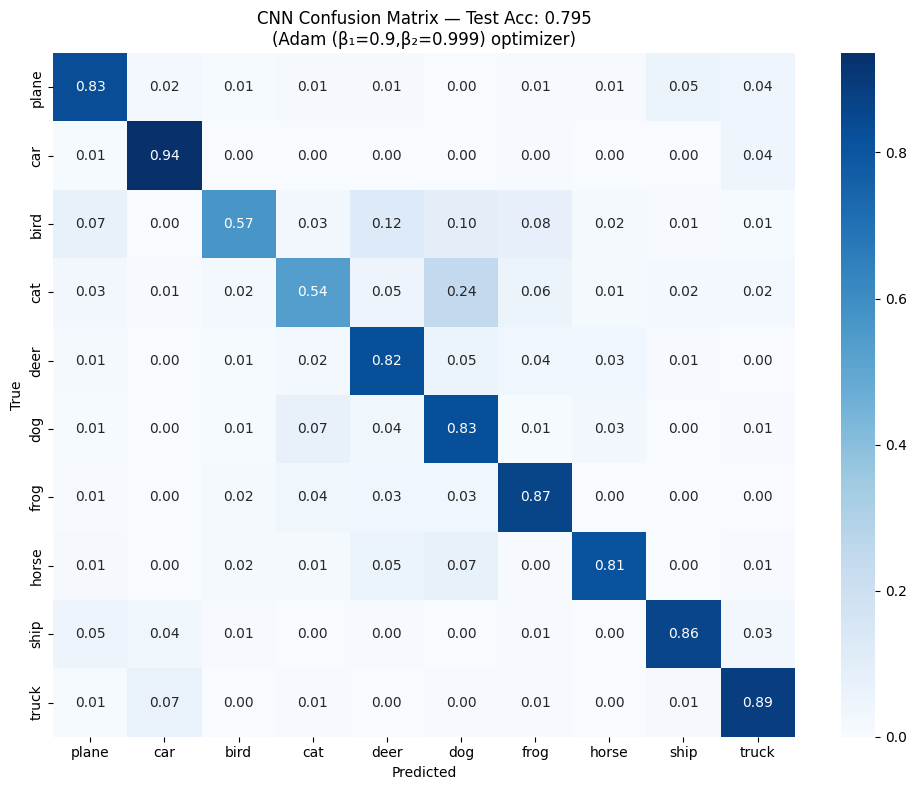


COMPLETE PROJECT SUMMARY — MLP vs CNN on CIFAR-10
        Model Type Train Acc Test Acc Gen Gap
 MLP Baseline  MLP    0.5700   0.5397 +0.0983
       MLP L2  MLP    0.6000   0.5566 +0.1718
  MLP Dropout  MLP    0.4904   0.4863 +0.0451
MLP BatchNorm  MLP    0.6082   0.5918 +0.0739
 MLP Full Reg  MLP    0.5151   0.5323 -0.0301
    MLP Tuned  MLP    0.5797   0.5779 +0.0001
   CNN (Best)  CNN    0.8074   0.7949 +0.0501


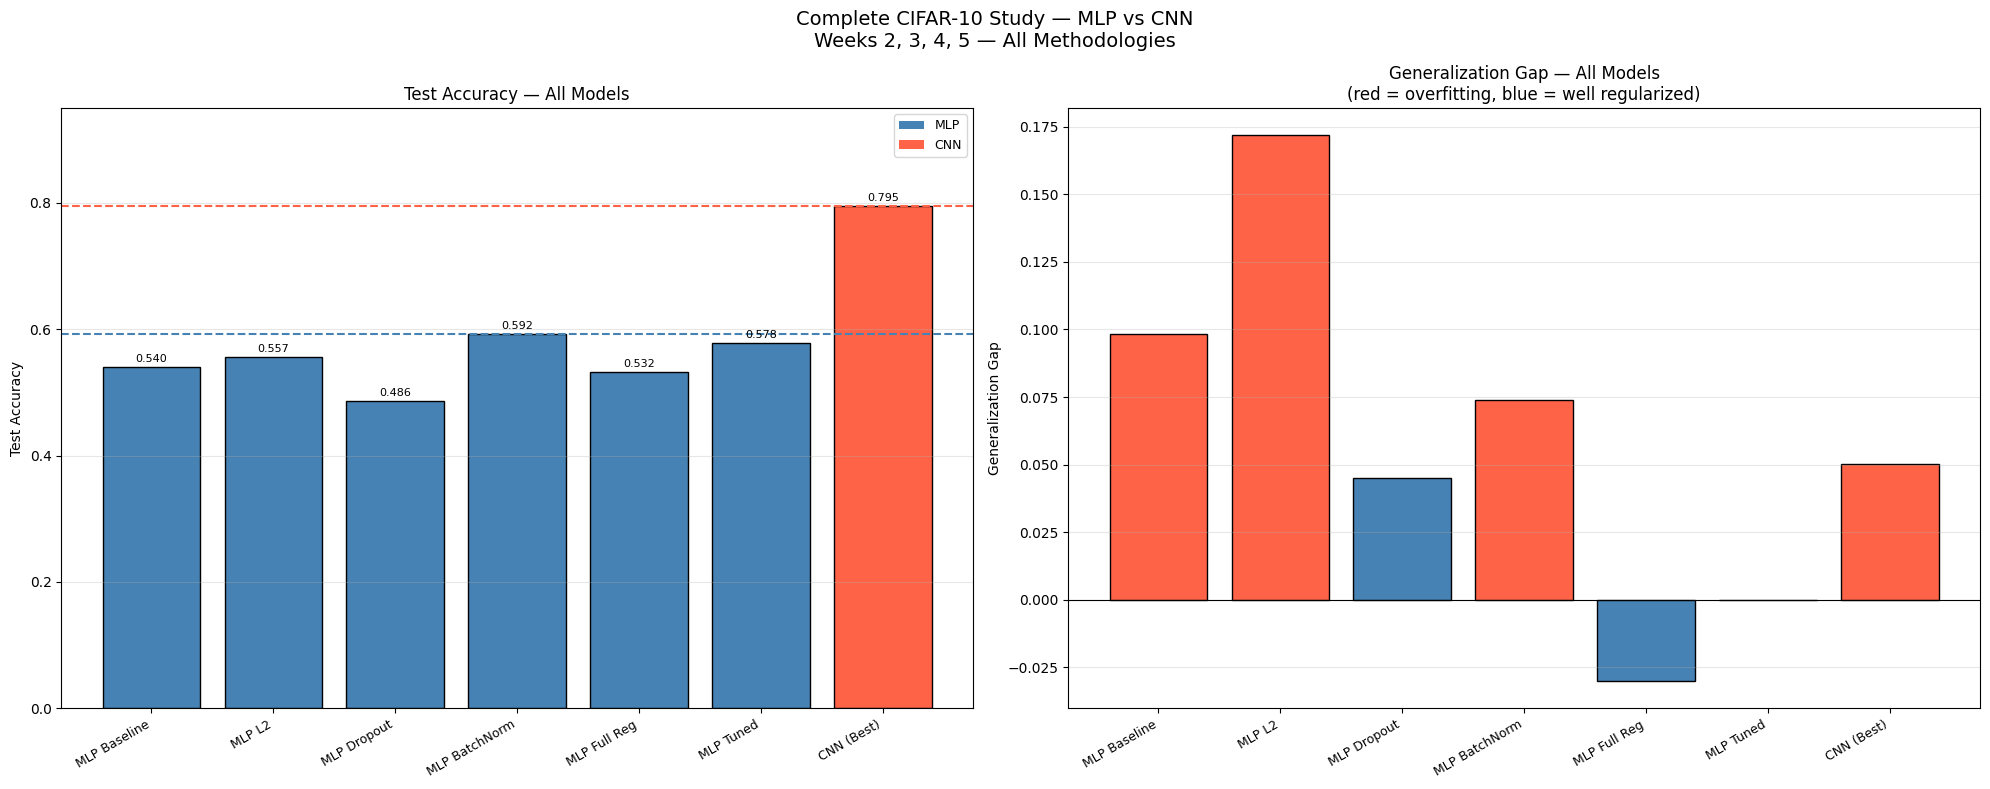

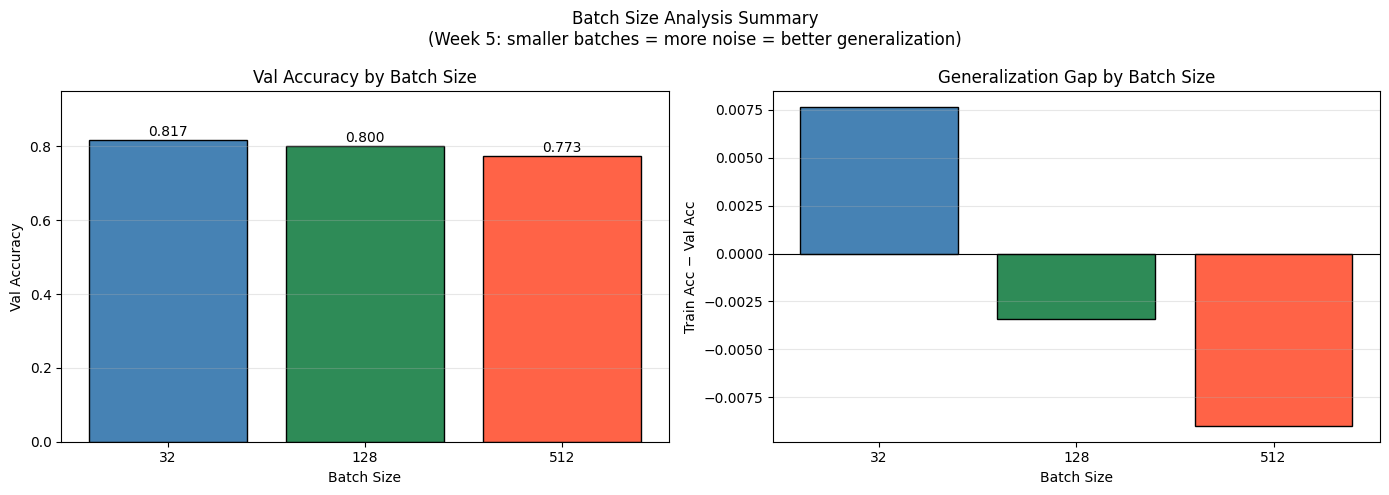


FINAL SUMMARY
Best MLP test accuracy  : 0.5918 (BatchNorm)
CNN test accuracy       : 0.7949 (Adam (β₁=0.9,β₂=0.999))
Improvement from CNN    : +0.2031 (+20.3%)

K-Fold CV (MLP):  0.5536 ± 0.0034

Week 5 findings:
  Best initializer : He ≈ Xavier (BN masks difference)
  He val acc:     0.7287
  Xavier val acc: 0.7300
  Best LR schedule : Warmup + Cosine Decay (0.8392)
  Best batch size  : 32 (0.8173)

All figures saved.


In [ ]:
# ============================================================
# CELL 18 — Final CNN Evaluation + Complete Project Summary
# ============================================================

# ── Pick best CNN from optimizer shootout ─────────────────────
best_opt_name = max(optimizer_results,
                    key=lambda n: optimizer_results[n]['val_acc'])
best_cnn      = optimizer_results[best_opt_name]['model']

print(f"Best optimizer: {best_opt_name.replace(chr(10),' ')}")
print(f"Val acc: {optimizer_results[best_opt_name]['val_acc']:.4f}")

# ── Evaluate best CNN on test set (first and only time) ───────
crit = nn.CrossEntropyLoss()
te_loss, te_acc, te_preds, te_labels = evaluate_model(
    best_cnn, test_loader, crit)
tr_loss, tr_acc, _, _ = evaluate_model(
    best_cnn, train_loader, crit)

print(f"\nCNN Test Results:")
print(f"  Train Acc : {tr_acc:.4f}")
print(f"  Test Acc  : {te_acc:.4f}")
print(f"  Gen Gap   : {tr_acc - te_acc:+.4f}")

# ── Per-class report ──────────────────────────────────────────
print("\nCNN Per-Class Classification Report:")
print("=" * 55)
print(classification_report(te_labels, te_preds, target_names=CLASSES))

# ── CNN confusion matrix ──────────────────────────────────────
cm      = confusion_matrix(te_labels, te_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f"CNN Confusion Matrix — Test Acc: {te_acc:.3f}\n"
          f"({best_opt_name.replace(chr(10),' ')} optimizer)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150)
plt.show()

# ── Complete results table ────────────────────────────────────
print("\n" + "=" * 70)
print("COMPLETE PROJECT SUMMARY — MLP vs CNN on CIFAR-10")
print("=" * 70)

all_model_results = {
    'MLP Baseline':  results['Baseline'],
    'MLP L2':        results['L2 Reg'],
    'MLP Dropout':   results['Dropout'],
    'MLP BatchNorm': results['BatchNorm'],
    'MLP Full Reg':  results['Full Reg'],
    'MLP Tuned':     results['Tuned'],
    'CNN (Best)': {
        'train_acc': tr_acc,
        'val_acc':   optimizer_results[best_opt_name]['val_acc'],
        'test_acc':  te_acc,
        'gen_gap':   te_loss - tr_loss,
        'best_epoch': optimizer_results[best_opt_name]['best_epoch']
    }
}

df_final = pd.DataFrame([
    {
        'Model':     name,
        'Type':      'CNN' if 'CNN' in name else 'MLP',
        'Train Acc': f"{v['train_acc']:.4f}",
        'Test Acc':  f"{v['test_acc']:.4f}",
        'Gen Gap':   f"{v['gen_gap']:+.4f}",
    }
    for name, v in all_model_results.items()
])
print(df_final.to_string(index=False))

# ── Final mega comparison chart ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Complete CIFAR-10 Study — MLP vs CNN\n"
             "Weeks 2, 3, 4, 5 — All Methodologies", fontsize=14)

names      = list(all_model_results.keys())
test_accs  = [all_model_results[n]['test_acc'] for n in names]
gen_gaps   = [all_model_results[n]['gen_gap']  for n in names]
bar_colors = ['tomato' if 'CNN' in n else 'steelblue' for n in names]

b = axes[0].bar(range(len(names)), test_accs,
                color=bar_colors, edgecolor='black')
for bar, acc in zip(b, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel("Test Accuracy")
axes[0].set_ylim(0, 0.95)
axes[0].set_title("Test Accuracy — All Models")
axes[0].axhline(te_acc,
                color='tomato', linestyle='--', linewidth=1.5,
                label=f'CNN: {te_acc:.3f}')
axes[0].axhline(results['BatchNorm']['test_acc'],
                color='steelblue', linestyle='--', linewidth=1.5,
                label=f"Best MLP: {results['BatchNorm']['test_acc']:.3f}")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

gc_colors = ['tomato' if g > 0.05 else 'steelblue' for g in gen_gaps]
axes[1].bar(range(len(names)), gen_gaps,
            color=gc_colors, edgecolor='black')
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel("Generalization Gap")
axes[1].set_title("Generalization Gap — All Models\n"
                  "(red = overfitting, blue = well regularized)")
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='MLP'),
                   Patch(facecolor='tomato',     label='CNN')]
axes[0].legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('complete_comparison.png', dpi=150)
plt.show()

# ── Batch size summary chart ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Batch Size Analysis Summary\n"
             "(Week 5: smaller batches = more noise = better generalization)",
             fontsize=12)

bs_list  = list(batch_results.keys())
val_accs = [batch_results[b]['val_acc']   for b in bs_list]
gaps     = [batch_results[b]['gen_gap']   for b in bs_list]
colors   = ['steelblue', 'seagreen', 'tomato']

axes[0].bar([str(b) for b in bs_list], val_accs,
             color=colors, edgecolor='black')
for i, (acc, bar) in enumerate(zip(val_accs,
        axes[0].patches)):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
axes[0].set_xlabel("Batch Size")
axes[0].set_ylabel("Val Accuracy")
axes[0].set_title("Val Accuracy by Batch Size")
axes[0].set_ylim(0, 0.95)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar([str(b) for b in bs_list], gaps,
             color=colors, edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel("Batch Size")
axes[1].set_ylabel("Train Acc − Val Acc")
axes[1].set_title("Generalization Gap by Batch Size")
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('batch_size_summary.png', dpi=150)
plt.show()

# ── Final numbers ─────────────────────────────────────────────
best_mlp_acc = results['BatchNorm']['test_acc']
improvement  = te_acc - best_mlp_acc

print(f"\n{'='*60}")
print(f"FINAL SUMMARY")
print(f"{'='*60}")
print(f"Best MLP test accuracy  : {best_mlp_acc:.4f} (BatchNorm)")
print(f"CNN test accuracy       : {te_acc:.4f} "
      f"({best_opt_name.replace(chr(10),' ')})")
print(f"Improvement from CNN    : {improvement:+.4f} "
      f"(+{improvement*100:.1f}%)")
print(f"\nK-Fold CV (MLP):  {mean_cv:.4f} ± {std_cv:.4f}")
print(f"\nWeek 5 findings:")
print(f"  Best initializer : He ≈ Xavier (BN masks difference)")
print(f"  He val acc:     "
      f"{init_results['He (Kaiming)']['val_acc']:.4f}")
print(f"  Xavier val acc: "
      f"{init_results['Xavier (Glorot)']['val_acc']:.4f}")
best_sched = max(sched_results,
                 key=lambda n: sched_results[n]['val_acc'])
print(f"  Best LR schedule : "
      f"{best_sched.replace(chr(10),' ')} "
      f"({sched_results[best_sched]['val_acc']:.4f})")
best_bs = max(batch_results,
              key=lambda b: batch_results[b]['val_acc'])
print(f"  Best batch size  : {best_bs} "
      f"({batch_results[best_bs]['val_acc']:.4f})")
print(f"\nAll figures saved.")

In [ ]:
# ============================================================
# CELL 19 — Regenerate Init & Optimizer Figures
# ============================================================

# ── Init comparison plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Initialization Comparison: Xavier vs He\n"
             "(Week 5: He multiplies variance by 2 to compensate "
             "for ReLU zeroing negatives)", fontsize=12)

colors = {'He (Kaiming)': 'steelblue', 'Xavier (Glorot)': 'tomato'}
for name, res in init_results.items():
    axes[0].plot(res['history']['train_loss'],
                 linestyle='--', color=colors[name], alpha=0.5)
    axes[0].plot(res['history']['val_loss'],
                 linestyle='-', color=colors[name], label=name)
    axes[1].plot(res['history']['val_acc'],
                 linestyle='-', color=colors[name], label=name)

axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[1].set_title("Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.4)
axes[0].annotate("Solid=Val | Dashed=Train",
                  xy=(0.02, 0.02), xycoords='axes fraction',
                  fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('init_comparison.png', dpi=150)
plt.show()

# ── Optimizer shootout plot ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Optimizer Shootout — CIFAR-10 CNN\n"
             "(Week 5: SGD→Momentum→RMSProp→Adam progression)",
             fontsize=13)

colors = plt.cm.tab10(np.linspace(0, 1, len(optimizer_histories)))
for (name, hist), color in zip(optimizer_histories.items(), colors):
    clean = name.replace('\n', ' ')
    axes[0].plot(hist['train_loss'], '--', color=color, alpha=0.4)
    axes[0].plot(hist['val_loss'],   '-',  color=color, label=clean)
    axes[1].plot(hist['val_acc'],    '-',  color=color, label=clean)

for ax, ylabel, title in zip(
        axes,
        ['Loss', 'Val Accuracy'],
        ['Loss Curves (Solid=Val, Dashed=Train)',
         'Validation Accuracy']):
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('optimizer_shootout.png', dpi=150)
plt.show()